In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from matplotlib.animation import FuncAnimation

# 静态偏微分-泊松方程

之前章节中的偏微分方程，包括波动方程，连续性方程，热传导方法都存在时间的偏导项，描述的是一个空间连续的物理量随时间的变化（如琴弦震动，电磁波中的电场，温度在介质中的传导等）。除了这种含时的偏微分方程，也存在一类不含时的静态偏微分方程，其中泊松方程（也称为位势方程）是物理学中常见的静态偏微分方程：

$ \nabla^2 u = \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} +\frac{\partial^2 u}{\partial z^2} \right) = \rho$

其中：
- $\rho(\mathbf{r},t)$: 为源项，表示空间$\mathbf{r}$处单位体积单位时间产生/吸收的物理量密度。

泊松方程可以描述多种物理过程：
- 含源热平衡：$\rho$代表加热或冷却源，$u$ 代表温度
- 静电场：$\rho$代表电荷密度分布，$u$ 代表静电势
- 引力场：$\rho$代表质量密度分布，$u$ 代表引力势

静态偏微分问题因没有时间的演化，因此不存在初始条件，其求解通常也被称为**边值问题**，即给定边界条件下求方程的解。这种情况下，虽然FTCS这种积分时间步长的方法不能被直接使用，但仍可以通过热传导的物理思想，转变为求解这类静态方程的方法，其最终形式类似于求解线性方程组，称为**松弛法**。

本章节将以热平衡问题引导出求解泊松方程类型静态偏微分问题的松弛法。

## 热平衡

之前介绍过的热传导方程，如果加入源项$\rho$:

$\frac{\partial u}{\partial t} + \rho= \kappa \nabla^2 u = \kappa \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} +\frac{\partial^2 u}{\partial z^2} \right)$

描述传热介质中的热量的变化。如果材料和热源处于稳定的状态，一段时间后，热量分布就会处于平衡，此时方程中的含时部分就会趋近于0，$\frac{\partial u}{\partial t}=0$，方程也转化为静态偏微分方程，形式上即为泊松方程：

$\rho = \kappa \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} +\frac{\partial^2 u}{\partial z^2} \right) $

### FTCS 方法求解热平衡过程

如果需要获得在恒定热源和边界条件下的温度的静态分布函数$u(\mathrm{r})$，则需要求解这个这平衡状态下的泊松方程。考虑热传导这种物理过程，在恒定热源下，系统会自然地达到热平衡状态。因此，如果我们直接用FTCS方法求解含时的热传导方程，并等待足够长时间，系统会自然地演化为热平衡状态，使求解的最终时刻的温度函数满足$\frac{\partial u}{\partial t}=0$。

首先，我们实现FTCS方法求解二维热传导方程的函数。在偏微分方程求解章节中，已经给出了案例。这里再介绍一种基于自然边界条件和Numpy数组计算的实现方法，在代码上更加简洁。

#### 自然边界条件

自然边界条件是指在边界上，物理量的空间导数等于零。对于二维泊松方程，自然边界条件可以表示为：

$\frac{\partial u}{\partial n} = 0$

其中，$\frac{\partial u}{\partial n}$ 表示法向导数，即在边界上指向外部的法向量与物理量的梯度的点积。

为了在有限差分方法中处理自然边界条件，我们可以在边界外创造一个虚拟格点（如下图所示），格点的值与边界处一致，这样对应的法向导数就会为0。

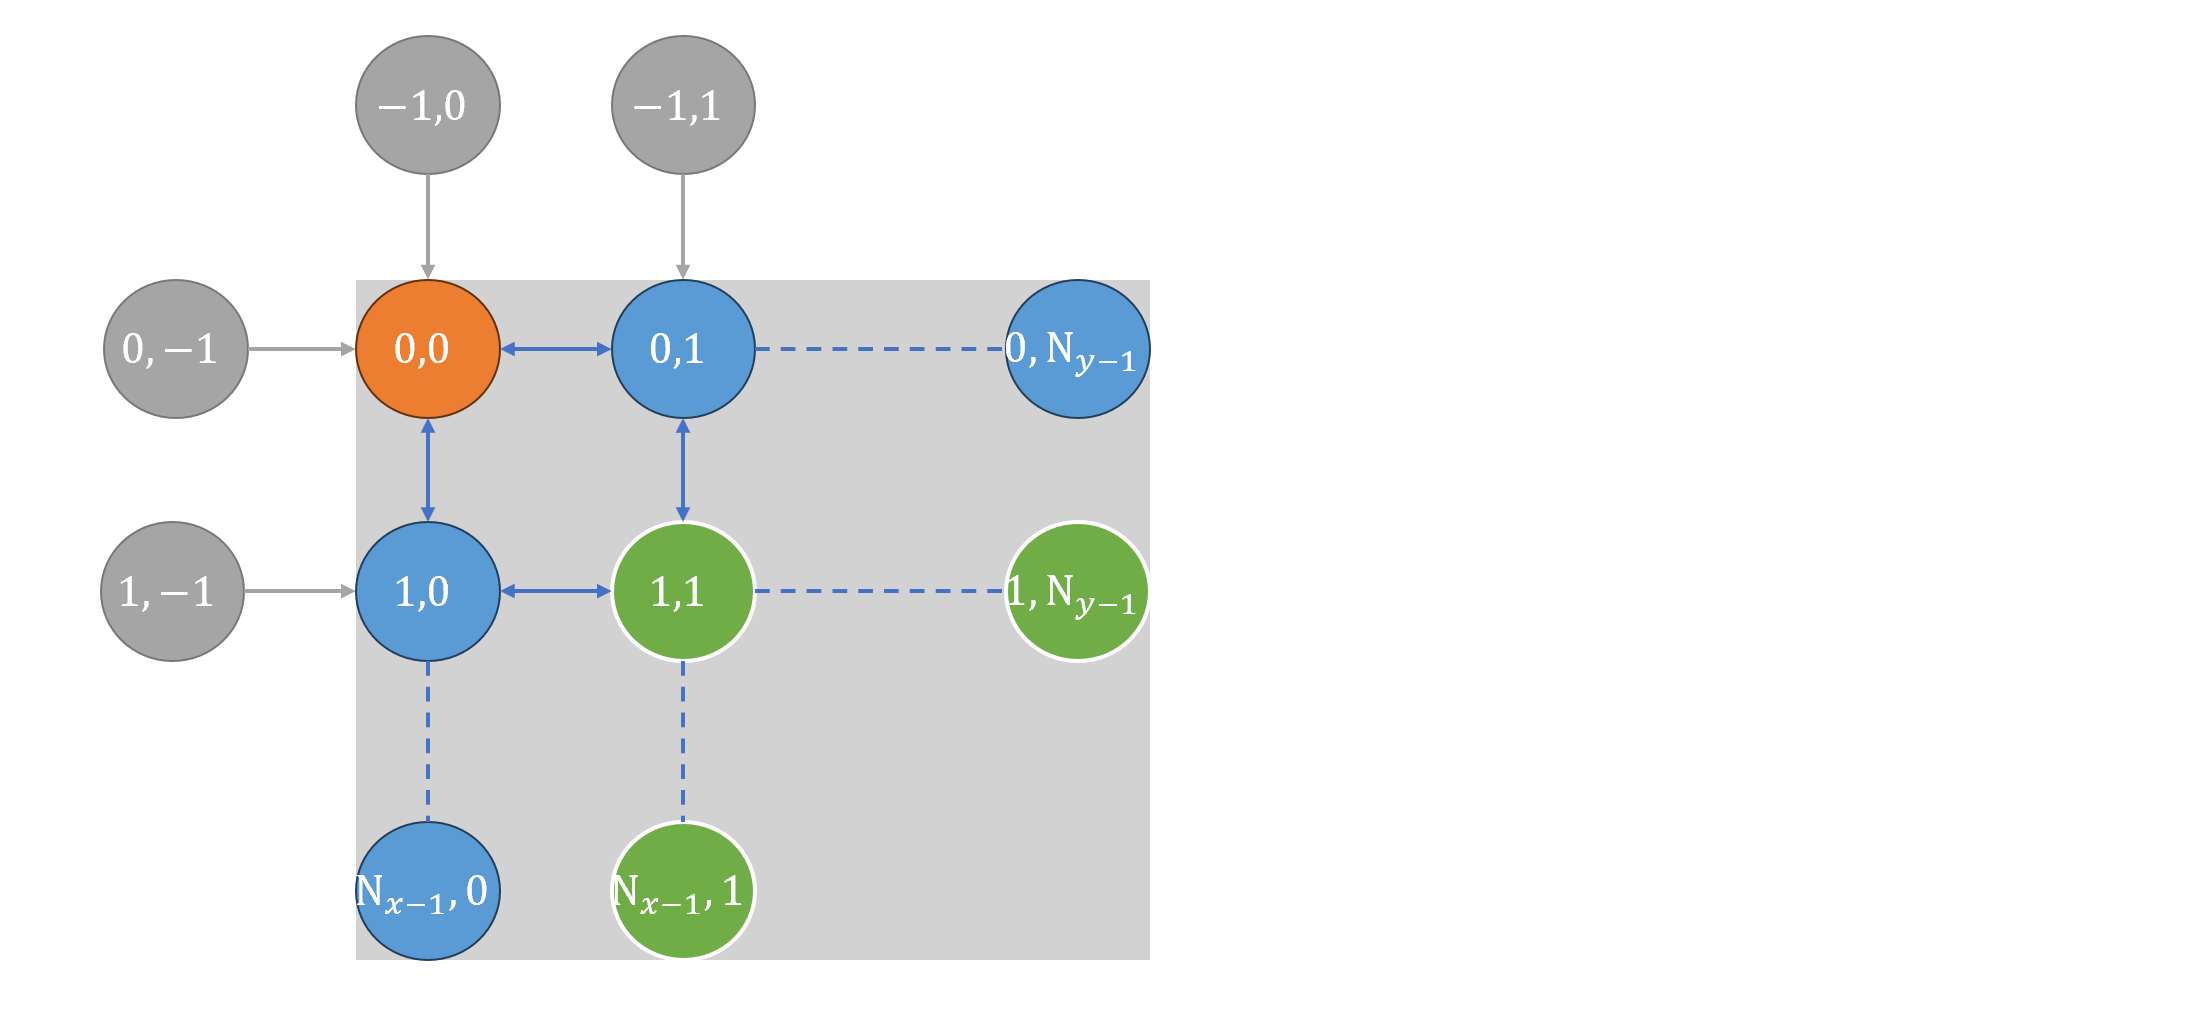

有了虚拟格点，我们首先观察中间格点的空间中心差分计算：

$\Delta u^{i,j} = u^{i+1,j} + u^{i-1,j} + u^{i,j+1} + u^{i,j-1} - 4u^{i,j}$

带入边界格点计算。我们分边线格点和顶点格点说明：

- 边线格点：

   在边界上的网格点 $(i,0)$ 处，自然边界条件对应的差分公式为：
   
   $\Delta u^{i,0} = u^{i+1,0} + u^{i-1,0} + u^{i,1} + u^{i,-1} - 4u^{i,0}$
   
   其中$u^{i,-1}$为虚拟格点，为保证法向导数为零，有$\frac{u^{i,-1} - u^{i,0}}{\Delta x} = 0$，即$u^{i,-1} = u^{i,0}$，则可得
   
   $\Delta u^{i,0} = u^{i+1,0} + u^{i-1,0} + u^{i,1} - 3u^{i,0} $
   
   类似地，对于其他边线格点，也可以使用类似的差分公式计算。
   
   
- 顶点格点：

   对于顶点$(0,0$)处，则有两个虚拟格点$u^{-1,0}=u^{0,-1} = u^{0,0}$，对应差分公式：

   $u^{0,0} = u^{1,0} + u^{0,1} - 2u^{0,0}$

   其他顶点格点类似。
   

#### 一维自然边界条件FTCS方法

我们先以较容易理解的一维自然边界为例，一维情况的中心格点空间差分为：

$u^{i+1} + u^{i-1} - 2 u^{i}$


之前实现差分计算的NumPy矢量化方法为：
```
# 先使用切片取出表征i+1, i , i-1的三组格点：
ui = u[1:-1]    # i
ui_pre = u[:-2] # i-1
ui_next = u[2:] # i+1

# 使用矢量运算计算非边界处的 du_i  = u_{i+1} + u_{i-1} - 2 u_i
du_mid = ui_next + ui_pre - 2*ui
```

自然边界条件下，边界格点差分：

- $u^{1} - u^{0}$
- $- (u^{-1} - u^{-2})$

对应python代码：
```
du_left = np.array([u[1] - u[0]])
du_right = np.array([u[-2] - u[-1]])

# 将边界和中间部分连接起来，并合并du/dt和dv/dt，构成最终的dwdt数组
du = np.concatenate((du_left, du_mid, du_right))

```

这种方法较为繁琐，边界点与中心格点需要分别处理再合并。对自然边界，有一种更简洁的方法。
首先，我们将中间格点的差分 $u^{i+1} + u^{i-1} - 2 u^{i}$ 分为两部分：

- $u^{i+1} - u^{i}$
- $- (u^{i} - u^{i-1})$

而左右边界的计算（见上面的差分表达式）只需要计算这两部分中的一个，因此可以在NumPy矢量化运算中随中心格点的计算一起得到，无需像上面那样单独拿出来计算。

此外，在矢量化运算中，这两部分计算都是右侧格点减左侧格点，仅仅是第二部分多出一个负号。因此通过一次运算，我们实际上可以得到一个格点两侧的差分，以及边界格点的差分。对应python代码：

```
dux = u[1:]- u[:-1]
```
注意到这个计算出的数组大小为N-1，其中格点数为N

然后，我们生成全零数组err，用于保存最终的差分值，也是误差项：
```
du = np.zeros(N)
```

之后的两部分差分，可以首先计算出左侧边界点的差分和中间格点的右侧差分：
```
du[:-1] = dux
```
这一步可以分为两步看：
```
du[0] = dux[0] = u[1] - u[0]
du[1:-1] = dux[1:] = u[2:] - u[1:-1]
```

再计算出右侧边界点的差分和中间格点的右侧差分：
```
du[1:] -= dux
```

这样，我们就同时完成了自然边界条件和中间格点的差分运算。

以下为一维自然边界条件的FTCS求解函数，并引入rho源项，与u0为相同维度的常数数组：

In [ ]:
def pde_ftcs_diffusion1d(u0, rho, dt, dx, k, nstep, bfunc=None, bargs=(), savefreq=1):
    """
    FTCS方法实现热传导（扩散）方程的求解，返回时间表tlist和求解结果ulist
    
    u0: 每个格点的u初值(一维） (u_0, u_1, ...)
    rho: 源项的离散化数组，与u0相同维度
    dt: 时间步长
    dx: 格点间距
    k: 热传导/扩散系数
    nstep: 总时间步数
    bfunc: 边界条件，依赖(u, t, dt, dx, k, *bargs)，计算边界并返回更新后的u，如果不提供，则使用自然边界条件
    bargs: bfunc依赖的额外参数，默认()
    savefreq: 存储数据的步长间隔，默认1
    """

    # 稳定性检测：
    if (2*k*dt/dx**2>1):
        raise ValueError('Stability test fail, should satisfy: 2k dt/dx^2 <=1')
        
    # 返回列表，存入初始值
    tlist = [0]
    ulist = [u0.copy()]

    # 定义求解数组，并复制初值
    u = u0.copy()
    
    # 求解循环
    for i in range(1,nstep+1):
    
        # 生成大小n的全零数组，存储每个格点空间差分的结果
        du = np.zeros(u.shape)
            
        # 计算相邻格点的差值
        dux = u[1:]-u[:-1]
        
        # 累积计算2次差值，分别实现左右两侧的差值,同时完成中间格点和两个边界自然边界条件的差分运算
        du[:-1] += dux
        du[1:]  -= dux
        
        # 前向差分，计算下一步u_next
        u_next = u + dt*(k/dx**2*du - rho)

        # 更新时间
        t = i*dt
        
        # 如果边界条件为非自然边界条件，使用bfunc基于u_next，更新u，否则直接令u=u_next
        if (bfunc):
            u = bfunc(u_next, t, dt, dx, k, *bargs)
        else:
            u = u_next

        # 存储u和时间t
        if (i%savefreq == 0):
            tlist.append(t)
            ulist.append(u.copy())
        
    return np.array(tlist), np.array(ulist)

#### 二维自然边界条件FTCS方法

接下来，我们实现二维情况的自然边界条件。
首先，我们可以把中间格点的计算差分的运算

$u^{i+1,j} + u^{i-1,j} + u^{i,j+1} + u^{i,j-1} - 4u^{i,j}$ 

分解为上下左右四个相邻格点的4次差值矢量运算：

- $u^{i+1,j} - u^{i,j}$
- $u^{i-1,j} - u^{i,j}$
- $u^{i,j+1} - u^{i,j}$
- $u^{i,j-1} - u^{i,j}$

自然边界条件下，边线格点的计算遵循相同规律，只是少了一个方向的差值方程（该方向为向边界外的法向方向，与虚拟格点的差值为0），顶点格点则是少了两个方向的差值方程。

接下来，我们用NumPy矢量化运算计算这个四个差值运算。而这四个运算可以简化为两次矢量运算：
- 中间与右边界 - 中间与左边界 （包括上下边界）：`u[1:, :] - u[:-1, :]` 或简化为 `u[1:] - u[:-1]`，结果为`dux`
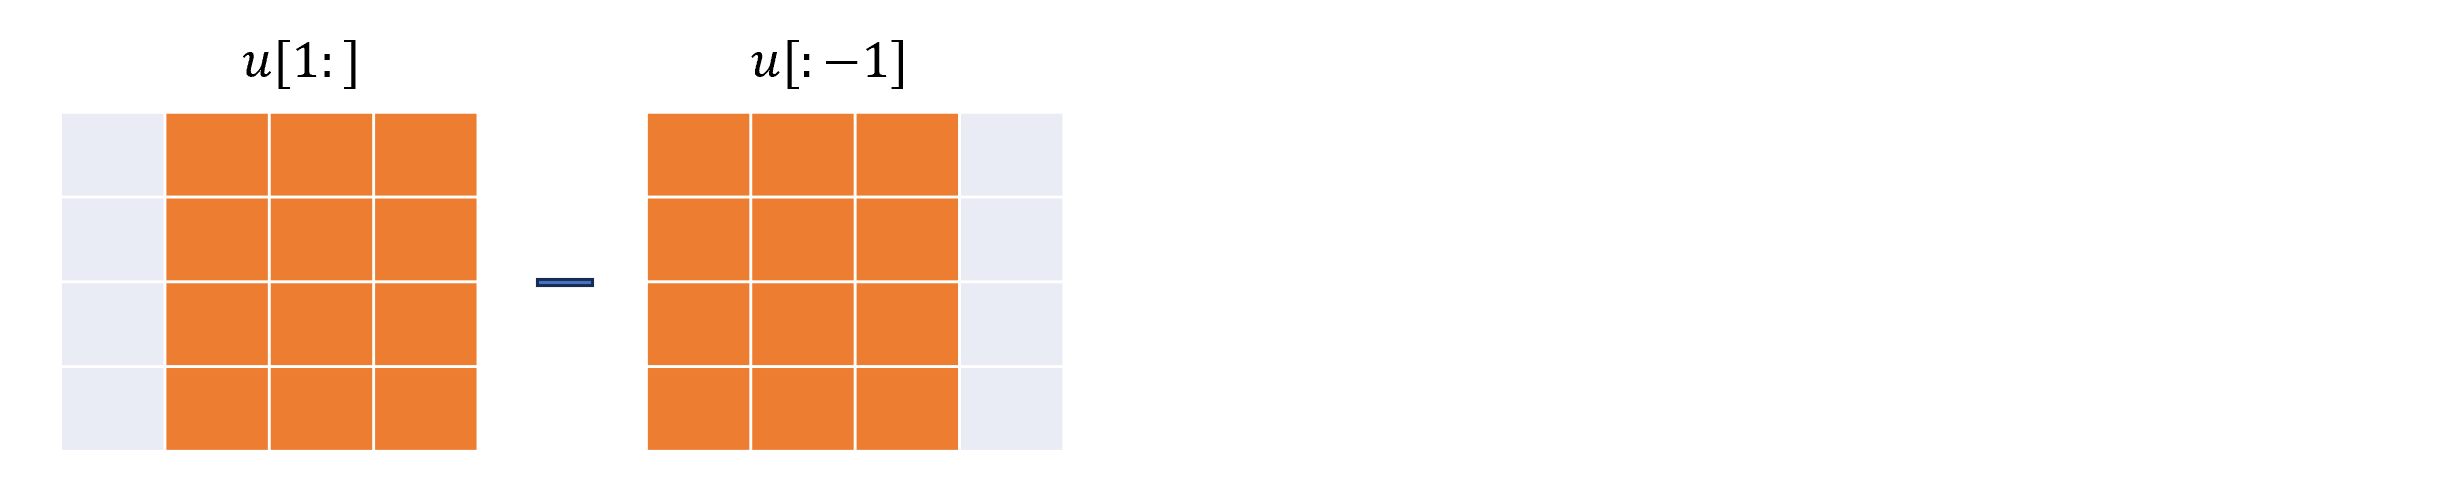
- 中间与下边界 - 中间与上边界 （包括左右边界）：`u[:, 1:] - u[:, :-1]`，结果为`duy`
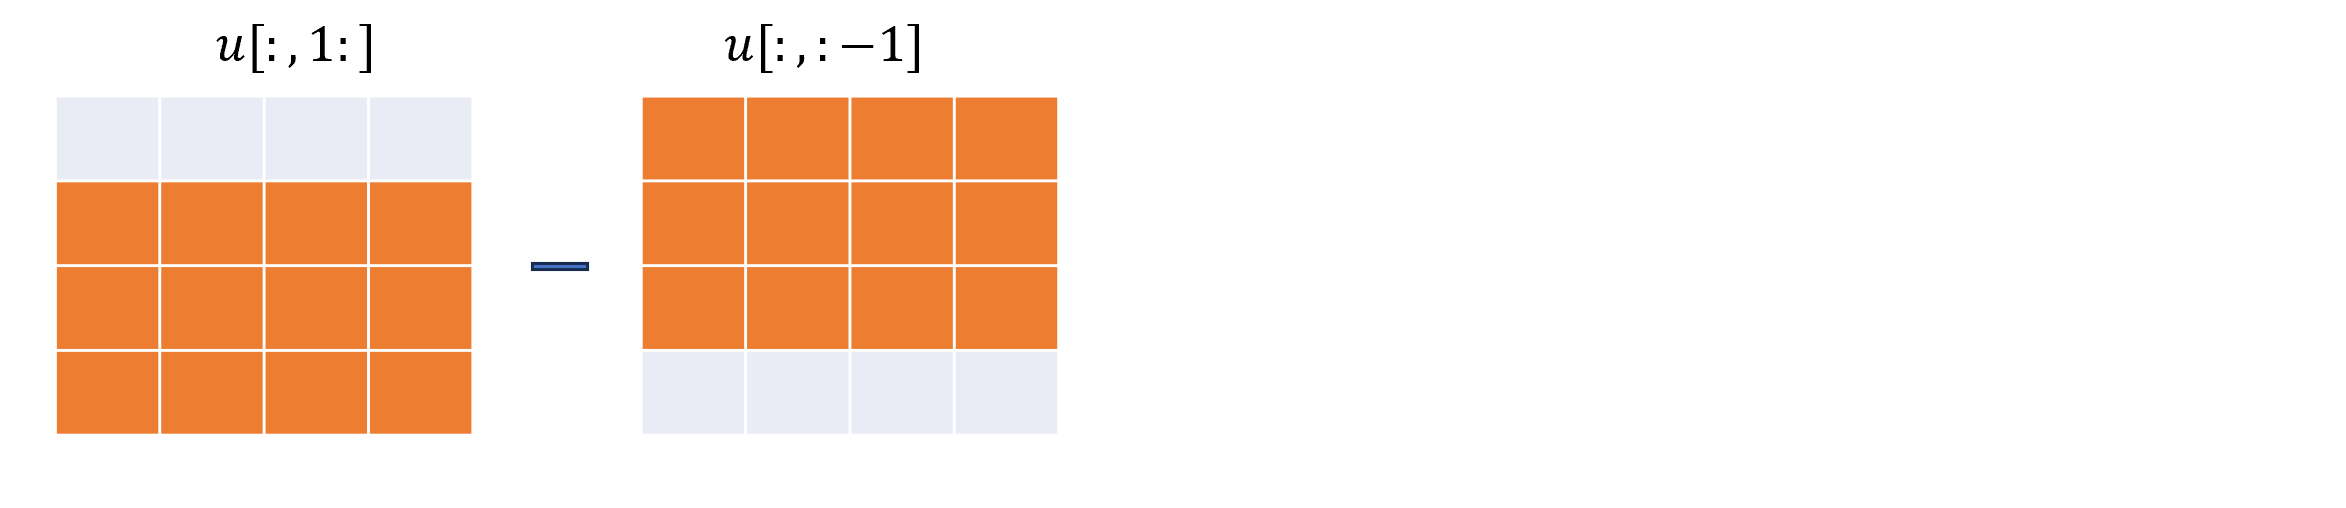

然后我们生成形状(nx,ny)的全零数组`du`，用于存储每个格点多次差分值总和。
依次计算：
- `du[:-1] += dux`: 表示除右边界的所有格点计算了一次右侧格点与自己的差值
- `du[1:] -= dux`:  表示除左边界的所有格点计算了一次左侧格点与自己的差值
- `du[:,:-1] += duy`: 表示除下边界的所有格点计算了一次下侧格点与自己的差值
- `du[:,:-1] -= duy`: 表示除上边界的所有格点计算了一次上侧格点与自己的差值

会发现，这样四次运算，就同时实现了中间格点的所有4次差值运算，以及边线格点的所有3次差值运算和4个顶点的所有两次差值运算。
因此，自然边界条件可以很简洁地融合到NumPy矢量化运算中，这也是我们为什么可以用它作为默认边界条件。

以下为使用二维自然边界条件的FTCS求解函数

In [ ]:
def pde_ftcs_diffusion2d(u0, rho, dt, dx, k, nstep, bfunc=None, bargs=(), savefreq=1):
    """
    FTCS方法实现热传导（扩散）方程的求解，返回时间表tlist和求解结果ulist
    
    u0: 每个格点的u初值(二维） (u_0,0, u_0,1, ...)
    rho: 源项的离散化数组，与u0相同维度
    dt: 时间步长
    dx: 格点间距
    k: 热传导/扩散系数
    nstep: 总时间步数
    bfunc: 边界条件函数，依赖(u, t, dt, dx, k, *bargs)，计算边界并返回更新后的u，如果不提供，则使用自然边界条件，无热源
    bargs: bfunc依赖的额外参数，默认()
    savefreq: 存储数据的步长间隔，默认1
    """

    # 稳定性检测：
    if (4*k*dt/dx**2>1):
        raise ValueError('Stability test fail, should satisfy: 4k dt/dx^2 <=1')
    
    # 返回列表，存入初始值
    tlist = [0]
    ulist = [u0.copy()]

    # 定义求解数组，并复制初值
    u = u0.copy()
    
    # 求解循环
    for i in range(1,nstep+1):
    
        # 生成形状(nx,ny)的全零数组，存储每个格点空间差分的结果
        du = np.zeros(u.shape)
            
        # 计算两个方向的差值
        dux = u[1:]-u[:-1]
        duy = u[:,1:]-u[:,:-1]
    
        # 累积计算4次差值，分别实现右左下上四个方向的差值,同时完成中间格点和四个边界自然边界条件的差分运算
        du[:-1] += dux
        du[1:]  -= dux
        du[:,:-1] += duy
        du[:,1:]  -= duy
        
        # 前向差分，计算下一步u_next
        u_next = u + dt*(k/dx**2*du - rho) 

        # 更新时间
        t = i*dt
        
        # 如果边界条件为非自然边界条件，使用bfunc基于u_next，更新u，否则直接令u=u_next
        if (bfunc):
            u = bfunc(u_next, t, dt, dx, k, *bargs)
        else:
            u = u_next

        # 存储u和时间t
        if (i%savefreq == 0):
            tlist.append(t)
            ulist.append(u.copy())
        
    return np.array(tlist), np.array(ulist)

### 案例：一维恒温边界的热平衡

我们求解边界为恒定温度10，中心有恒定热源$\rho_m=-1$的一维介质达到热平衡状态的温度分布，满足方程：

$\frac{\partial u}{\partial t} + \rho = \kappa \frac{\partial^2 u}{\partial x^2}$

- 边界条件：所有边界格点为恒定值10
- 热源：在中心格点处为-1（注意负值代表放热），其他区域为0
- 初始条件：温度与边界一致，全为10
- 参数: dx=1, k=1, dt =0.5，满足稳定条件

In [ ]:
N = 51
x = np.linspace(0,N-1,N)

#初始温度
u0 = np.random.rand(N)*10+10
#u0 = np.ones(N)*10

# 格点间距
dx = x[1]-x[0]

# 时间步长
dt = 0.5

# 热传导系数
k = 1

# 热源数组，除中间点为24，其他区域都为0
rho = np.zeros(N)
rho[24] = -1

print('dx=',dx,'dt=',dt,'k=',k)

# 边界条件+热源
def bfunc(u, t, dt, dx, k):
    u[0] = 10
    u[-1] = 10
    return u

带入FTCS求解

In [ ]:
nsteps = 4000
savefreq = 20

tlist, ulist = pde_ftcs_diffusion1d(u0, rho, dt, dx, k, nsteps, bfunc=bfunc, savefreq=savefreq)
print(ulist.shape) # 三维，（时间，x格点, y格点)

将求解结果绘制为动画

In [ ]:
fig, axes = plt.subplots(1,1, figsize=(4,3))
plot, = axes.plot(x, ulist[0])
axes.set_title('T = 0')
axes.set_ylim(10,24)
plt.tight_layout()

def anime_loop(k):
    time = tlist[k]
    plot.set_data(x, ulist[k])
    axes.set_xlabel('x')
    axes.set_ylabel('y')
    axes.set_title('T = %.1f' % time)
    
    return plot
    
n_frames = tlist.shape[0]
anime = FuncAnimation(fig, anime_loop, frames = n_frames, interval=20, repeat=False)

In [ ]:
anime.event_source.stop()

In [ ]:
anime.save('thermal_1d_r.mp4',dpi=300)

### 案例：二维随机温度涨落回到热平衡

我们以一个初始时刻有温度涨落的二维介质为例，温度演化满足二维方程：

$\frac{\partial u}{\partial t} = \kappa \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$

热传导过程的最终状态应为整个介质处于与边界相同温度的等温体，我们使用FTCS求解热传导方程观察温度的演化过程。

对于我们要求解的热平衡问题，我们可以使用自然边界条件，因此无需设置边界条件函数。对初始条件，我们让格点上的温度产生一个随机高斯涨落分布。高斯函数的中心温度为24，标准差为20，用`np.random.randn`实现。二维CFL稳定条件为 $\frac{2k \Delta t}{\Delta x^2} \le \frac{1}{2}$, 格点间距为1，热传导系数为1，对应时间步长取0.1。

In [ ]:
Nx = 51
Ny = 51
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)

u0 = np.random.randn(Nx, Ny)*20 + 24 # 初始随机温度

# 格点间距
dx = rx0[1]-rx0[0]

# 源项全为0
rho = np.zeros(u0.shape)

# 时间步长
dt = 0.1

# 热传导系数
k = 1

print('dx=',dx,'dt=',dt,'k=',k)

画图显示初始状态

In [ ]:
# 画图显示初始状态
fig = plt.figure(figsize=(8,3))
plt.gca().set_aspect('equal')
plt.pcolormesh(ry0, rx0, u0, cmap='hot')
cb = plt.colorbar()
cb.set_label('Temperature')

带入FTCS方法求解

In [ ]:
nsteps = 50
savefreq = 1

tlist, ulist = pde_ftcs_diffusion2d(u0, rho, dt, dx, k, nsteps, savefreq=savefreq)
print(ulist.shape) # 三维，（时间，x格点, y格点)

生成一个动画绘制函数，将求解结果绘制为动画

In [ ]:
fig, axes = plt.subplots(1,1, figsize=(4,4))
umin = ulist[0].min()
umax = ulist[0].max()
plot = axes.imshow(ulist[0], cmap='hot', vmin=umin, vmax=umax, animated=False)
cb = fig.colorbar(plot, ax=axes)    
cb.set_label('Temperature')
axes.set_title('T = 0')
axes.set_aspect(1)

def anime_loop(k):
    time = tlist[k]
    plot.set_data(ulist[k])
    axes.set_xlabel('x')
    axes.set_ylabel('y')
    axes.set_title('T = %.1f' % time)
    
    return []
    
n_frames = tlist.shape[0]
anime = FuncAnimation(fig, anime_loop, frames = n_frames, interval=200, repeat=False)

可以看到，一开始的温度涨落随着时间会逐渐耗散，系统逐渐达到与边界温度相同的等温状态。其最终时刻的解`ulist[-1]`即为对应的静态偏微分方程的解。

In [ ]:
anime.event_source.stop()

In [ ]:
anime.save('thermal_equal.mp4',dpi=300)

## 松弛法 (Relaxation Method)

我们可以将热平衡求解的物理概念推广到各种由泊松方程 $\nabla^2 u = \rho$ 描述的静态偏微分问题的求解：

1. 在泊松方程中加入时间偏导，将偏微分方程转化为：

   $\frac{\partial u}{\partial t} = \nabla^2 \varphi - \rho$
   
   在代码实现中，我们可以将 $\rho$ 作为边界条件加入 `bfunc` 函数，或者将其写入 `dudt_func` 中作为有限差分的一部分。
   
2. 该方程的时间演化会自然导向平衡态。我们使用FTCS等有限差分方法求解该方程，直到某一时刻 $\frac{\partial \varphi}{\partial t}$ 在所有格点上趋近于零。此时，$\varphi$ 的值即为泊松方程的解。

这种求解泊松方程的方法被称为**松弛法**。泊松方程通常描述的是一个物理量的稳态，因此，“松弛”一词可以形象地理解为当物理系统处于不稳定状态时，这种状态会随时间推移逐渐“放松”，最终回到稳定的状态。

松弛法（Relaxation Method）源自一种用于求解线性方程组的迭代方法。它通过不断更新变量的近似值来逐步逼近方程组的解。其基本思想是将线性方程组转化为迭代形式，即将方程组中的每个变量表示为其他变量的线性组合，然后通过不断迭代更新这些变量的值，直到达到一定的收敛条件。

我们以二维泊松方程为例：

$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \rho$

我们可以使用线性方程组求解的形式来描述松弛法求解该方程：先使用类似于FTCS方法处理空间偏导的有限差分方法，对空间格点进行离散化，同时使用差分来求解每个格点处 $u^{i,j}$ 的空间偏导数，可以得到表征泊松方程的有限差分方程：

$u^{i+1,j} + u^{i-1,j} + u^{i,j+1} + u^{i,j-1} - 4 u^{i,j} = \Delta x^2 \rho^{i,j}$

我们将 $u^{i,j}$ 的二维矩阵展开成一维向量的形式 $(u^{0,0}, u^{0,1}, ..., u^{1,0}, u^{1,1}, ...)$，同时对 $\rho$ 进行相同的向量化操作，可以将上述方程写成以下线性方程组（矩阵运算）的形式：

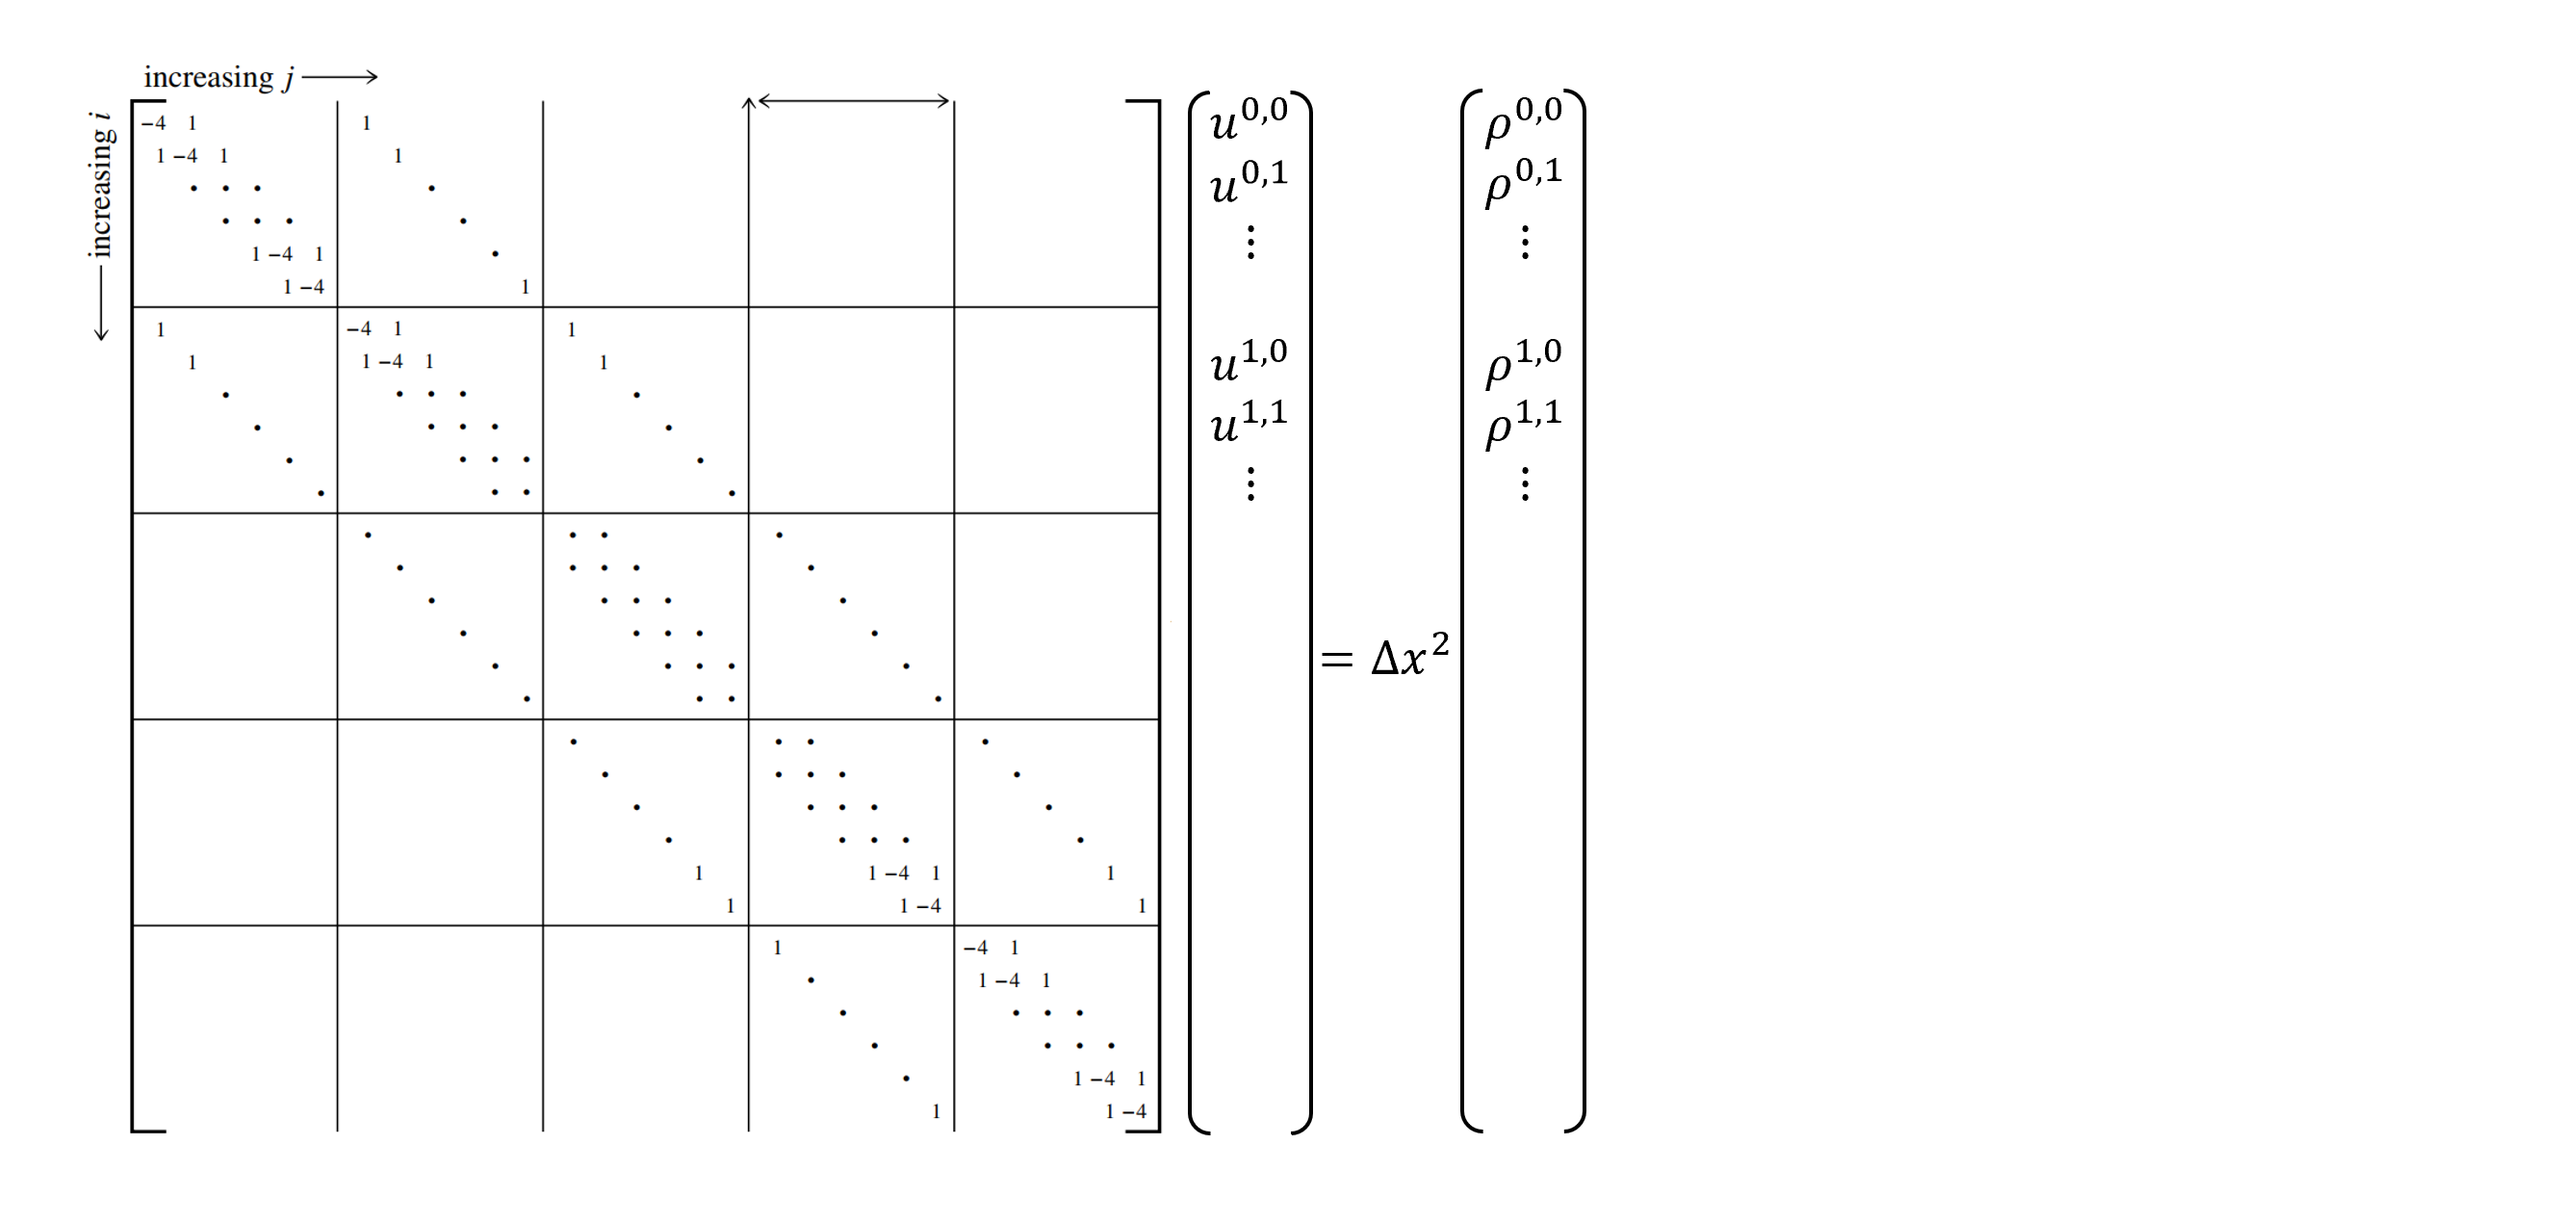

对比FTCS求解带时间偏导的热传导方程的公式：

$u^{i,j}_{k+1}= u^{i,j}_k + \Delta t \frac{\kappa}{\Delta x^2} \left( u^{i+1,j}_k + u^{i-1,j}_k + u^{i,j+1}_k + u^{i,j-1}_k - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$

发现这种方法等价于求解上图中线性方程组的迭代算法。具体来说，我们定义松弛因子$\omega$替换针对热传导方程中的系数$\frac{\kappa \Delta t}{\Delta x^2}$，得到等价的松弛法表达式：

$u^{i,j}_{k+1}= u^{i,j}_k + \frac{1}{4}{\omega} \left( u^{i+1,j}_k + u^{i-1,j}_k + u^{i,j+1}_k + u^{i,j-1}_k - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$

通过调节$\omega$值，实际上相当于改变FTCS方法中的时间步长与空间格点的配比。而$\omega$前的$1/4$系数可以使得当$\omega=1$时，方程右侧的$u^{i,j}_k$项消去，同时保证求解过程能够稳定。

另外，$\omega$后的部分，即差分计算结果如果等于零，则对应的$u^{i,j}_k$就是方程的精确解，如果不等于零，这一部分的值则能表征迭代过程的误差。因此，我们定义误差项

$\epsilon^{i,j}_{k+1} = u^{i,j}_{k+1}- u^{i,j}_k =  \frac{1}{4}{\omega} \left(u^{i+1,j}_k + u^{i-1,j}_k + u^{i,j+1}_k + u^{i,j-1}_k - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$

得到松弛法的简化表达式：

$\epsilon^{i,j}_{k+1} = \frac{1}{4}{\omega} \left(u^{i+1,j}_k + u^{i-1,j}_k + u^{i,j+1}_k + u^{i,j-1}_k - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$

该公式说明，松弛法的迭代思想即每次根据上一步的误差修正$u^{i,j}_k$，使下一步的误差减小得到更精确的方程解。

类似的，不同维度的松弛法迭代步骤：
- 一维：$u^{i}_{k+1} = u^{i}_k + \frac{1}{2}{\omega} \left(u^{i+1}_k + u^{i-1}_k - 2 u^{i}_k - \Delta x^2\rho^{i}\right )$
- 二维：$u^{i,j}_{k+1} = u^{i,j}_k +  \frac{1}{4}{\omega} \left(u^{i+1,j}_k + u^{i-1,j}_k + u^{i,j+1}_k + u^{i,j-1}_k - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$
- 三维：$u^{i,j,l}_{k+1} = u^{i,j,l}_k +  \frac{1}{6}{\omega} \left(u^{i+1,j,l}_k + u^{i-1,j,l}_k + u^{i,j+1,l}_k + u^{i,j-1,l}_k + u^{i,j,l+1}_k + u^{i,j,l-1}_k - 6 u^{i,j,l}_k - \Delta x^2\rho^{i,j,l}\right )$

### 代码实现
我们将之前FTCS算法改写一下，得到一维和二维松弛法求解泊松方程的算法：

In [ ]:
def pde_relax_possion1d(u0, rho, dx, omega=1, bfunc=None, bargs=(), tol=1e-10, niter_max=10000, savefreq=1):
    """
    求解一维泊松方程的松弛法
    bfunc没有定义时，默认边界处为自然边界条件
    
    参数:
    -----------
    u0: 泊松方程解的初始猜测值数组
    rho: 源项的离散化数组，与u0相同维度
    dx: 格点间距
    omega: 松弛因子，默认1
    bfunc: 边界条件函数，参数(u, dx, omega, *bargs):
           如果边界条件函数未提供，默认自然边界条件
           返回：加入边界条件后的u
    bargs: bfunc格外参数，封装为元组()
    tol: 误差允许最大值，默认1e-10
    niter_max: 最大迭代步长，默认10000
    savefreg: 迭代结果存储频率，默认每一步都存（1）

    返回:
    -------
    ulist: 求解过程中每次迭代的值，三维numpy数组，形状(nsteps/savefreq, nx, ny)
    errlist: 求解过程中每次差分值，同时也代表误差
    """
    
    # 返回量，定义待求解u和差分（误差）du的列表，每次迭代向列表添加求解值
    ulist = []
    errlist = []
    
    # 定义每次迭代的u
    # 对numpy数组，使用copy函数将在内存上创建新数组，将u0数据复制给u
    # 直接用u=u0可能只是传递u0内存地址赋值给u（类似C++指针），导致u0数据在后续迭代中被改写
    u = u0.copy()     

    # 迭代次数
    niter = 0
    err_max = tol*10 # 初始误差设为tol十倍，保证进入迭代循环
    
    # 数据存储时设为True,否则为False
    save_flag = False
    
    # 迭代循环，当误差满足要求，以及迭代次数超过最大时退出迭代
    while (err_max > tol) & (niter <niter_max) | ((err_max <= tol) & (not save_flag)):
        
        # 生成大小n的全零数组，存储每个格点空间差分的结果
        du = np.zeros(u.shape)
            
        # 计算相邻格点的差值
        dux = u[1:]-u[:-1]
        
        # 累积计算2次差值，分别实现左右两侧的差值,同时完成中间格点和两个边界自然边界条件的差分运算
        du[:-1] += dux
        du[1:]  -= dux
        
        # 计算下一步u_next
        u_next = u + 1/2*omega*(du - dx**2*rho)
        
        # 如果bfunc不为None，带入边界条件更新u_next
        if bfunc:
            u_next = bfunc(u_next, dx, omega, *bargs)

        # 计算误差
        err = u_next - u
        
        # 获得最大误差
        err_max = np.abs(err).max()

        # 更新u
        u = u_next
        
        # 根据输出频率存储迭代结果与误差du
        if (niter%savefreq == 0):
            ulist.append(u.copy())
            errlist.append(err.copy())

        niter += 1
            
    return np.array(ulist), np.array(errlist)

In [ ]:
def pde_relax_possion2d(u0, rho, dx, omega=1, bfunc=None, bargs=(), tol=1e-10, niter_max=100000, savefreq=1):
    """
    求解二维泊松方程的松弛法
    bfunc没有定义时，默认边界处为自然边界条件
    
    参数:
    -----------
    u0: 泊松方程解的初始猜测值，二维numpy数组，形状(nx,ny)
    rho: 源项的离散化数组，与u0相同维度
    dx: 格点间距
    omega: 松弛因子，默认1
    bfunc: 边界条件，参数(u, dx, omega, *bargs):
           如果边界条件函数未提供，默认自然边界条件
           返回：加入边界条件后的u
    bargs: bfunc格外参数，封装为元组()
    tol: 误差允许最大值，默认1e-10
    niter_max: 最大迭代步长，默认10000
    savefreg: 迭代结果存储频率，默认每一步都存（1）

    返回:
    -------
    ulist: 求解过程中每次迭代的值，三维numpy数组，形状(nsteps/savefreq, nx, ny)
    errlist: 求解过程中每次差分值，同时也代表误差
    """
    
    # 返回量，定义待求解u和差分（误差）du的列表，每次迭代向列表添加求解值
    ulist = []
    errlist = []
    
    # 定义每次迭代的u
    # 对numpy数组，使用copy函数将在内存上创建新数组，将u0数据复制给u
    # 直接用u=u0可能只是传递u0内存地址赋值给u（类似C++指针），导致u0数据在后续迭代中被改写
    u = u0.copy()     

    # 迭代次数
    niter = 0
    err_max = tol*10 # 初始误差设为tol十倍，保证进入迭代循环

    # 数据存储时设为True,否则为False
    save_flag = False
    
    # 迭代循环，当误差满足要求，以及迭代次数超过最大时退出迭代
    while (err_max > tol) & (niter < niter_max) | ((err_max <= tol) & (not save_flag)):
        
        # 生成形状(nx,ny)的全零数组，存储每个格点空间差分的结果
        du = np.zeros(u0.shape)
            
        # 计算两个方向的差值
        dux = u[1:]-u[:-1]
        duy = u[:,1:]-u[:,:-1]
    
        # 累积计算4次差值，分别实现右左下上四个方向的差值,同时完成中间格点和四个边界自然边界条件的差分运算
        du[:-1] += dux
        du[1:]  -= dux
        du[:,:-1] += duy
        du[:,1:]  -= duy

        # 更新u
        u_next = u + 1/4*omega*(du - dx**2*rho)
        
        # 如果bfunc不为None，带入边界条件更新u_next
        if bfunc:
            u_next = bfunc(u_next, dx, omega, *bargs)

        # 计算误差
        err = u_next - u
        
        # 获得最大误差
        err_max = np.abs(err).max()

        # 更新u
        u = u_next
        
        # 根据输出频率存储迭代结果与误差du
        if (niter%savefreq == 0):
            ulist.append(u.copy())
            errlist.append(err.copy())
            save_flag = True
        else:
            save_flag = False

        niter += 1
            
    return np.array(ulist), np.array(errlist)

### 案例：存在放热与吸热源的二维介质热平衡下热量分布

我们举一个含源热平衡的例子：求解存在一个冷却源与一个发热源的二维系统的温度分布：

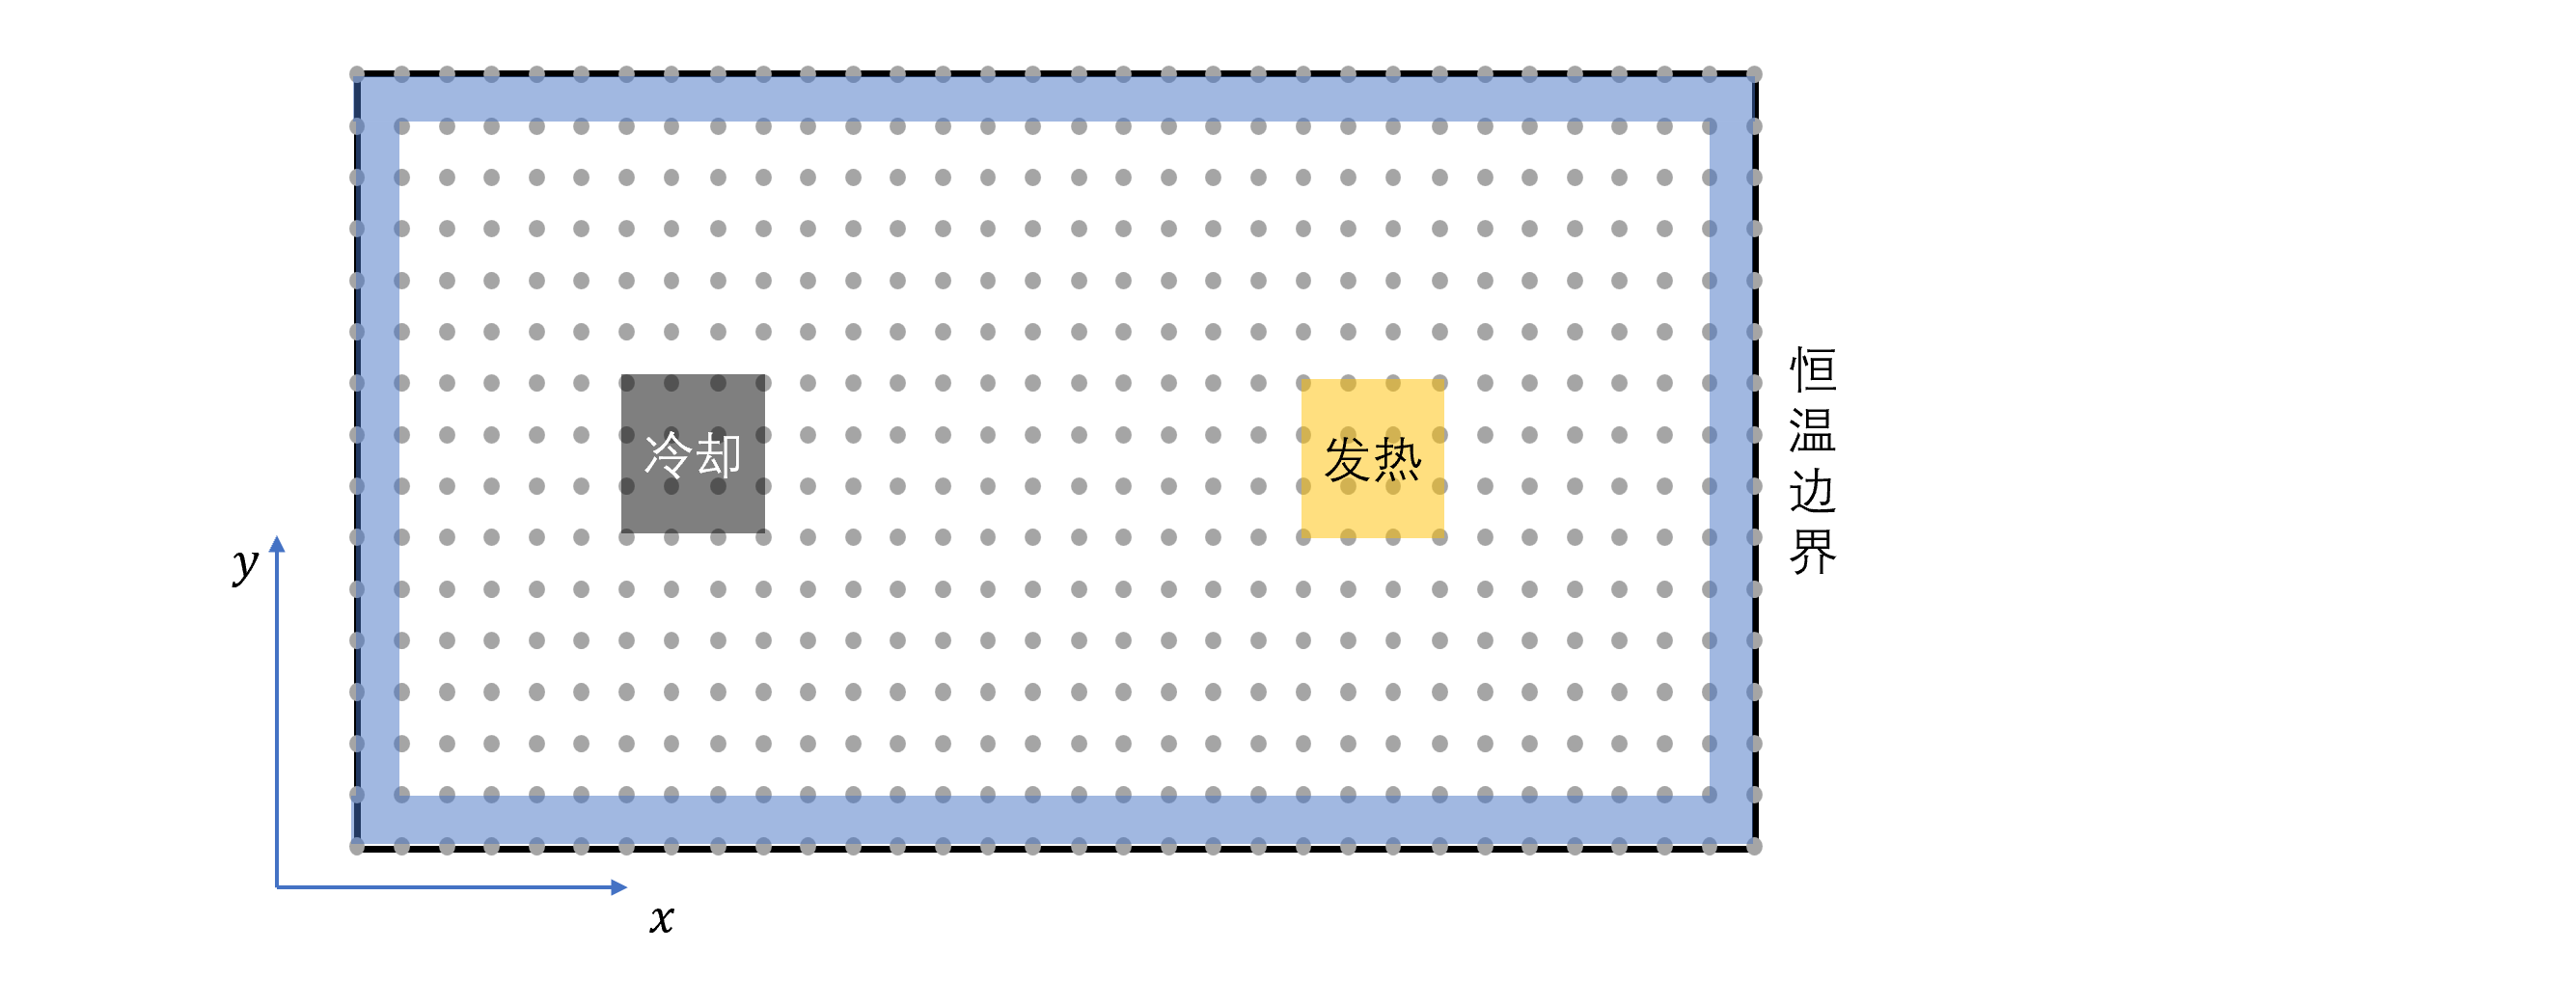

具体参数：
- 矩形二维介质，格点数为`(51,101)`。
- 边界条件：恒温边界，值为24
- 热源：小块矩形区域`[20:30,20:30]`，`[20:30，-30:-20]`分别设置为发热源$\rho=-1$和吸收源$\rho=1$，
- 初始条件：等温`24`

利用松弛法求解热平衡时整个介质的温度分布：

In [ ]:
# 格点初始化
Nx = 51
Ny = 101
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 边界条件
def bfunc(u, dx, omega):
    # 将四周边界du/dt设为0，使用numpy切片实现选取边界点
    u[0,:] = 24 
    u[-1,:] = 24
    u[:,0] = 24
    u[:,-1] = 24

    return u

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

带入松弛法求解

In [ ]:
# 存储间隔
savefreq = 100

# 带入松弛法计算
ulist, errlist = pde_relax_possion2d(u0, rho, dx, bfunc=bfunc, savefreq=savefreq)
print(ulist.shape)

生成绘制动画函数，同时显示u值和误差分布

In [ ]:
def anime_possion2d(ulist, errlist, savefreq):
    fig, axes = plt.subplots(2,1,figsize=(6,6))
    umin = -10
    umax = 60
    plot = axes[0].imshow(ulist[0], cmap='hot', vmin=umin, vmax=umax)
    cb = fig.colorbar(plot, ax=axes[0])    
    cb.set_label('u')
    axes[0].set_title('iteration:  0')
    axes[0].set_aspect(1)
    axes[0].set_ylabel('y')
    
    errlist[errlist==0] = 1e-11
    logerr = np.log10(np.abs(errlist))
    emin = -11
    emax = 1
    error = axes[1].imshow(logerr[0], cmap='hot', vmin=emin, vmax=emax)
    cb2 = fig.colorbar(error, ax=axes[1])    
    cb2.set_label('du')
    axes[1].set_title('err:  %g' % np.abs(errlist[0]).max())
    axes[1].set_aspect(1)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    
    def anime_loop(k):
        plot.set_data(ulist[k])
        error.set_data(logerr[k])
        axes[0].set_title('iteration:  %d' % (k*savefreq))
        axes[1].set_title('error:  %g' % (np.abs(errlist[k]).max()))
        
        return []
        
    n_frames = ulist.shape[0]
    anime = FuncAnimation(fig, anime_loop, frames = n_frames, interval=20, repeat=False)
    return anime

In [ ]:
anime = anime_possion2d(ulist, errlist, savefreq)

In [ ]:
anime.event_source.stop()

In [ ]:
anime.save('thermal_relax_2d.mp4')

### 迭代效率与稳定性

松弛法需要多少次迭代才能得到一定精度的结果，以及算法是否稳定，可以通过分析冯诺依曼稳定性判据来分析。

首先，我们定义

$u_n^{i,j} = \xi_n e^{I i k_i \Delta x} e^{I j k_j \Delta x}$

表示每个格点上振动模式为$k_i,k_j$ （x和y两个方向）的特征值。

将$u_n^{i,j}$带入到松弛法，得到冯诺依曼稳定性判据：

$g(\Delta t, \Delta x, k_i, k_j) = \frac{u_{n+1}^{i,j} }{u_{n}^{i,j} } =  1 - \omega  \left [ \sin^2 \frac{k_i\Delta x}{2} + \sin^2 \frac{k_j\Delta x}{2} \right ]$

当$|g(\Delta t, \Delta x, k_i, k_j)|$越接近0，振动耗散越快，收敛所需的迭代次数越少。

另外，对于不同的振动模式$k_i,k_j$，收敛效率也会随着$\Delta x$取值而变化。将各个振动模式收敛（耗散）最慢的称为松弛算法的**谱半径**$\rho_s$。

因此，谱半径可以用于衡量松弛法的迭代效率与稳定性。可以近似估算松弛法到特定精度$10^{-p}$所需要的迭代次数为

$N \approx \frac{p }{-\log_{10} \rho_s}$

## 超松弛法（successive overrelaxtion）

### 松弛法的不稳定性

利用FTCS方法推演来的松弛法效率并不高，特别是由于稳定性条件的限制$\omega\le1$，我们无法通过调大松弛因子$\omega>1$使收敛更高效。我们仍用上面热平衡的例子来检验$\omega =1.01$时的表现：

In [ ]:
# 格点初始化
Nx = 51
Ny = 101
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 边界条件
def bfunc(u, dx, omega):
    # 将四周边界du/dt设为0，使用numpy切片实现选取边界点
    u[0,:] = 24 
    u[-1,:] = 24
    u[:,0] = 24
    u[:,-1] = 24

    return u

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

# 其他参数不改变，只调整omega
omega = 1.9
# 设定迭代次数为100
niter_max = 100
# 存储间隔
savefreq=1
# 带入松弛法计算
ulist, errlist = pde_relax_possion2d(u0, rho, dx, omega, bfunc=bfunc, niter_max=niter_max, savefreq=savefreq)
# 绘制动画
anime = anime_possion2d(ulist, errlist, savefreq)
#ani.save('sor_fail.mp4')

In [ ]:
anime.event_source.stop()

In [ ]:
anime.save('thermal_relax_unstable.mp4')

可以看到，结果直接发散了，误差越来越大，这表明我们不能随意改变松弛因子使其大于1。这样的限制使得松弛法求解泊松方程效率很低，需要很多步的迭代才能收敛到一定精度。

但通过一些特殊的算法改进，我们可以实现$\omega>1$的快速收敛，接下来我们介绍这一类超松弛算法(successive overrelaxtion; SOR)。

### 棋盘松弛法

通过一点简单的改造，我们可以生成一种超松弛算法，大幅提高迭代效率。其方法是将空间网格分为奇格和偶格，类似国际象棋的黑白棋盘格，如下图所示：

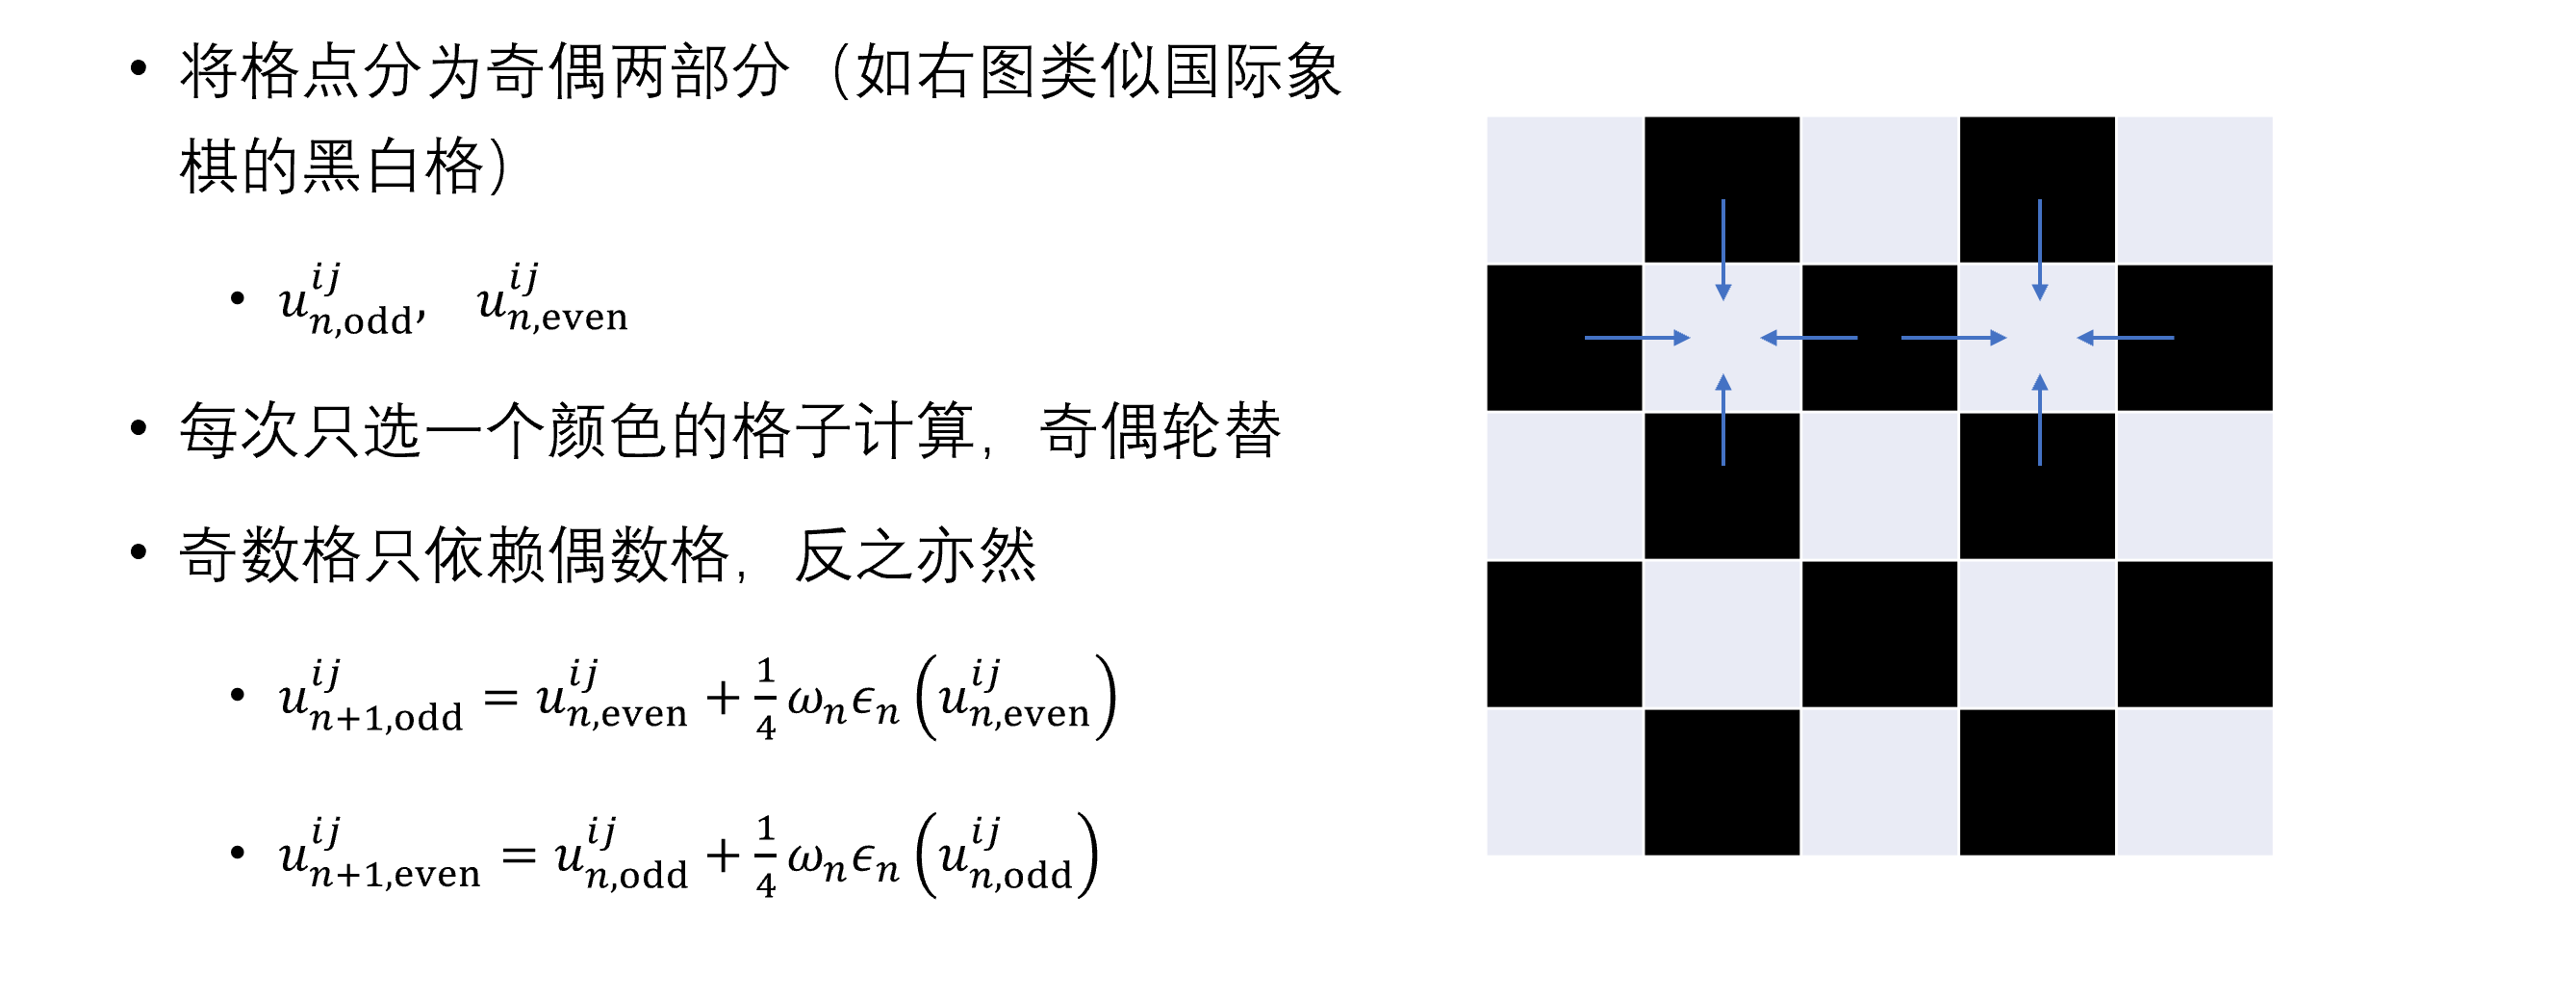

这种奇偶错位的计算方式，能够有效增加计算稳定性，使得松弛因子$\omega>1$算法能够稳定。

根据谱半径分析，可得到收敛效率最高的超松弛因子 $\omega_{opt} \approx \frac{2}{1 + \sin{(\pi/N)}}$，其中$N$为x和y方向的最小格点数。

我们对之前的松弛法函数稍加改造，即可实现棋盘松弛法。

In [ ]:
def pde_checkerboard_possion2d(u0, rho, dx, omega=None, bfunc=None, bargs=(), tol=1e-10, niter_max=10000, savefreq=1):
    """
    求解二维泊松方程的超松弛法，每次迭代交替计算奇网格或偶网格
    bfunc没有定义时，默认边界处为自然边界条件
    
    参数:
    -----------
    u0: 泊松方程解的初始猜测值，二维numpy数组，形状(nx,ny)
    rho: 源项的离散化数组，与u0相同维度
    dx: 格点间距
    omega: 松弛因子，默认为最佳值 2/(1+sin(pi/min(nx,ny)))
    bfunc: 边界条件函数，参数(u,dx,omega,*bargs):
           如果边界条件函数未提供，默认自然边界条件
           返回： 加入边界条件后的u
    bargs: bfunc格外参数，封装为元组()
    tol: 误差允许最大值，默认1e-10
    niter_max: 最大迭代步长，默认10000
    savefreg: 迭代结果存储频率，默认每一步都存（1）

    返回:
    -------
    ulist: 求解过程中每次迭代的值，三维numpy数组，形状(nsteps/savefreq, nx, ny)
    errlist: 求解过程中每次差分值，同时也代表误差
    """

    nx, ny = u0.shape
    
    if (not omega):
        omega = 2/(1+np.sin(np.pi/np.minimum(nx,ny)))
        print(f'omega: {omega}')
    
    # 返回量，定义待求解u和差分（误差）du的列表，每次迭代向列表添加求解值
    ulist = []
    errlist = []
    
    # 定义每次迭代的u
    # 对numpy数组，使用copy函数将在内存上创建新数组，将u0数据复制给u
    # 直接用u=u0可能只是传递u0内存地址赋值给u（类似C++指针），导致u0数据在后续迭代中被改写
    u = u0.copy() 

    # 迭代次数
    niter = 1
    err_max = tol*10 # 初始误差设为tol十倍，保证进入迭代循环

    # 迭代循环，当误差满足要求，以及迭代次数超过最大值两倍，退出迭代
    while (err_max > tol) & (niter < niter_max):

        u_old = u.copy()

        # 分奇数和偶数两部迭代
        for k in [0,1]:
            # 生成形状(nx,ny)的全零数组，存储每个格点空间差分的结果
            du = np.zeros(u0.shape).astype(u0.dtype)
                
            # 计算两个方向的差值
            dux = u[1:]-u[:-1]
            duy = u[:,1:]-u[:,:-1]
        
            # 累积计算4次差值，分别实现右左下上四个方向的差值,同时完成中间格点和四个边界自然边界条件的差分运算
            du[:-1] += dux
            du[1:]  -= dux
            du[:,:-1] += duy
            du[:,1:]  -= duy
    
            # 更新u
            u_next = u + 1/4*omega*(du - dx**2*rho)        
            
            # 如果bfunc不为None，使用边界条件函数更新u_next
            if bfunc:
                u_next = bfunc(u_next, dx, omega, *bargs)
            
            # 每次迭代k会从0，1之间切换，利用k,可以将交替将奇数或偶数网格的du值设为0
            u[k::2,1::2] = u_next[k::2, 1::2] # 只更新y索引为奇数，x索引为偶/奇数序列设
            u[1-k::2,::2] = u_next[1-k::2,::2] # 只更新y索引为偶数，x索引为奇/偶数序列设，与上面错开
        
        # 计算误差
        err = u - u_old
        err_max = np.abs(err).max()
        
        # 根据输出频率存储误差，只有偶数步输出
        if (niter%(savefreq) == 0):
            ulist.append(u.copy())
            errlist.append(err)
            
        niter += 1
            
    return np.array(ulist), np.array(errlist)

演示上诉函数中奇偶步的实现方法：如何通过k使每次计算的奇数格点或偶数格点err为0

In [ ]:
for i in range(4):
    k = (i%2)
    err = np.ones((5,5))
    err[k::2,1::2] = 0
    err[1-k::2,::2] = 0
    print('k=',k,'err:')
    print(err)

#### 案例：测试热平衡迭代效率

现在我们再次实现对热平衡问题的计算，这次使用最佳超松弛因子，看到同样的误差需要多少迭代次数：

In [ ]:
# 格点初始化
Nx = 51
Ny = 101
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 边界条件
def bfunc(u, dx, omega):
    # 将四周边界du/dt设为0，使用numpy切片实现选取边界点
    u[0,:] = 24 
    u[-1,:] = 24
    u[:,0] = 24
    u[:,-1] = 24

    return u

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

# 存储间隔
savefreq = 10
# 带入松弛法计算
ulist, errlist = pde_checkerboard_possion2d(u0, rho, dx, bfunc=bfunc, savefreq=savefreq)
# 绘制动画
anime = anime_possion2d(ulist, errlist, savefreq)

In [ ]:
anime.event_source.stop()

In [ ]:
anime.save('thermal_checkerboard.mp4')

可以看到，使用棋盘松弛法，只需要200步（如果奇偶步单独算，共迭代400次），就能迭代到误差量级$10^{-10}$，相比之前的松弛法快近25倍。因此这是一种很有效的泊松方程求解算法。可以进一步测试松弛因子的极限，会发现当$\omega=2$，求解结果发生振荡而不再稳定。

#### 冯诺依曼稳定性分析

我们使用冯诺依曼稳定性分析来查看为何$\omega>1$时,棋盘松弛法能够稳定

In [ ]:
import sympy as sy
xi = sy.Symbol('xi')
ki = sy.Symbol('k_i')
kj = sy.Symbol('k_j')
dx = sy.Symbol('\Delta x')
omega = sy.Symbol('w')

定义特征模式初始条件数组

In [ ]:
Nx = 4
Ny = 4
u0 = np.array([[xi*sy.exp(sy.I*i*ki*dx + sy.I*j*kj*dx) for i in range(Nx)] for j in range(Ny)])
rho = np.zeros(u0.shape).astype(sy.Symbol)
sy.Matrix(u0)

首先用标准松弛法，计算增长因子

In [ ]:
u = u0.copy()

for i in range(1):
    
    # 生成形状(nx,ny)的全零数组，存储每个格点空间差分的结果
    du = np.zeros(u0.shape).astype(u0.dtype)
        
    # 计算两个方向的差值
    dux = u[1:]-u[:-1]
    duy = u[:,1:]-u[:,:-1]

    # 累积计算4次差值，分别实现右左下上四个方向的差值,同时完成中间格点和四个边界自然边界条件的差分运算
    du[:-1] += dux
    du[1:]  -= dux
    du[:,:-1] += duy
    du[:,1:]  -= duy

    # 更新u
    u += omega*(du - dx**2*rho)/4 

g = sy.simplify(u[1,1]/u0[1,1])
g

再使用棋盘松弛法，得到增长因子表达式

In [ ]:
u = u0.copy()

for i in range(2):
    
    # 生成形状(nx,ny)的全零数组，存储每个格点空间差分的结果
    du = np.zeros(u0.shape).astype(u0.dtype)
        
    # 计算两个方向的差值
    dux = u[1:]-u[:-1]
    duy = u[:,1:]-u[:,:-1]

    # 累积计算4次差值，分别实现右左下上四个方向的差值,同时完成中间格点和四个边界自然边界条件的差分运算
    du[:-1] += dux
    du[1:]  -= dux
    du[:,:-1] += duy
    du[:,1:]  -= duy

    # 更新u
    u_next = u + omega*(du - dx**2*rho)/4 
    
    # 根据迭代次数niter只更新奇数网格或偶数网格，可以通过将偶数网格或奇数网格的du设为0实现
    k = (i%2) # niter对2取余，得到0或1，表征偶数或奇数
    
    # 每次迭代k会从0，1之间切换，利用k,可以将交替将奇数或偶数网格的du值设为0
    u[k::2,1::2] = u_next[k::2, 1::2] # 只更新y索引为奇数，x索引为偶/奇数序列设
    u[1-k::2,::2] = u_next[1-k::2,::2] # 只更新y索引为偶数，x索引为奇/偶数序列设，与上面错开

gsor = sy.simplify(u[1,1]/u0[1,1])
gsor

增长因子表达式过于复杂，我们进行数值分析，将增长因子转换为函数

In [ ]:
g_func = sy.lambdify([omega,ki,kj,dx],g)
gsor_func = sy.lambdify([omega,ki,kj,dx],gsor)

遍历$k_i \Delta x, k_j \Delta x$，查看增长因子的模（实部）

In [ ]:
x = np.linspace(0,np.pi)
y = np.linspace(0,np.pi)
xm, ym = np.meshgrid(x,y)
omega = 2
gm = g_func(omega, xm, ym, 1)
gm2 = gsor_func(omega, xm, ym, 1)

fig, axes = plt.subplots(1,2, figsize=(8,3))
gm[xm**2+ym**2>np.pi**2] = np.inf
plot = axes[0].pcolormesh(x, y, np.abs(gm.real), vmin=0, vmax=1)
axes[0].set_aspect(1)
cb = plt.colorbar(plot)
cb.set_label('|g|')
axes[0].set_xlabel(r'$k_i \Delta x$')
axes[0].set_ylabel(r'$k_j \Delta x$')

gm2[xm**2+ym**2>np.pi**2] = np.inf
plot = axes[1].pcolormesh(x, y, np.abs(gm2.real), vmin=0, vmax=1)
axes[1].set_aspect(1)
cb = plt.colorbar(plot)
cb.set_label('|g|')
axes[1].set_xlabel(r'$k_i \Delta x$')
axes[1].set_ylabel(r'$k_j \Delta x$')

plt.tight_layout()

可发现，在$\omega=2$情况下，虽然两种方法$|g| \le 1$，但标准松弛法在$x$和$y$都为高频的区域$|g|$接近1，表明这部分在迭代中不会耗散，因此在存在数值误差时容易产生不稳定性。棋盘松弛法高频处$|g|<1$，可以将高频模式耗散掉，因此可以在$\omega>1$时仍保持稳定。

### 基于松弛法迭代过程改进的超松弛法

除了利用棋盘格的模式实现超松弛法，我们还可以在原松弛法基础上，稍作调整，即可实现超松弛法。

在基于FTCS方法推导而来的松弛法中，下一步的迭代值$u_{k+1}$只依赖于上一步$u_{k}$的计算，但如果我们在迭代计算过程中，$u_{k+1}$可以依赖已经更新过的部分临近格点值，可以使松弛法的效率更高，且能实现$\omega>1$超松弛收敛。

以一维举例，之前松弛法中间格点的迭代公式：

$u^{i}_{k+1} = u^{i}_k + \frac{1}{2}{\omega} \left(u^{i+1}_k + u^{i-1}_k - 2 u^{i}_k - \Delta x^2\rho^{i}\right )$

如果用for循环实现格点计算，在计算$u^{i}_{k+1}$这一点时，$u^{i-1}_{k+1}$已在上一步计算出，因此可以直接用更新后的值代替$u^{i-1}_k$，对应新的迭代公式：

$u^{i}_{k+1} = u^{i}_k + \frac{1}{2}{\omega} \left(u^{i+1}_k + u^{i-1}_{k+1} - 2 u^{i}_k - \Delta x^2\rho^{i}\right )$

通过实践可发现，这样的松弛法在 $\omega =1$ 时迭代收敛效率更高，且 $\omega<2$ 时能够稳定，可实现超松弛收敛。

类似的，对二维和三维的迭代公式，可以将之前已完成更新的i-1,j-1,l-1对应值改为更新后的值，实现超松弛法的改进：

- 二维：$u^{i,j}_{k+1} = u^{i,j}_k +  \frac{1}{4}{\omega} \left(u^{i+1,j}_k + u^{i-1,j}_{k+1} + u^{i,j+1}_k + u^{i,j-1}_{k+1} - 4 u^{i,j}_k - \Delta x^2\rho^{i,j}\right )$
- 三维：$u^{i,j,l}_{k+1} = u^{i,j,l}_k +  \frac{1}{6}{\omega} \left(u^{i+1,j,l}_k + u^{i-1,j,l}_{k+1} + u^{i,j+1,l}_k + u^{i,j-1,l}_{k+1} + u^{i,j,l+1}_k + u^{i,j,l-1}_{k+1} - 6 u^{i,j,l}_k - \Delta x^2\rho^{i,j,l}\right )$

以下，我们实现二维改进后的超松弛法：

In [ ]:
def pde_sor_possion2d(u0, rho, dx, omega=None, bfunc=None, bargs=(), tol=1e-10, niter_max=100000, savefreq=1):
    """
    求解二维泊松方程的（超）松弛法
    bfunc没有定义时，默认边界处为自然边界条件
    
    参数:
    -----------
    u0: 泊松方程解的初始猜测值，二维numpy数组，形状(nx,ny)
    rho: 源项的离散化数组，与u0相同维度
    dx: 格点间距
    omega: 松弛因子，默认为最佳值 2/(1+sin(pi/min(nx,ny)))
    bfunc: 边界条件，参数(u, dx, omega, *bargs):
           如果边界条件函数未提供，默认自然边界条件
           返回：加入边界条件后的u
    bargs: bfunc格外参数，封装为元组()
    tol: 误差允许最大值，默认1e-10
    niter_max: 最大迭代步长，默认10000
    savefreg: 迭代结果存储频率，默认每一步都存（1）

    返回:
    -------
    ulist: 求解过程中每次迭代的值，三维numpy数组，形状(nsteps/savefreq, nx, ny)
    errlist: 求解过程中每次差分值，同时也代表误差
    """

    # 获得网格数
    nx, ny = u0.shape
    
    # 计算最佳松弛因子
    if (not omega):
        omega = 2/(1+np.sin(np.pi/np.minimum(nx,ny)))
        print(f'omega: {omega}')
        
    # 返回量，定义待求解u和差分（误差）du的列表，每次迭代向列表添加求解值
    ulist = []
    errlist = []
    
    # 定义每次迭代的u
    # 对numpy数组，使用copy函数将在内存上创建新数组，将u0数据复制给u
    # 直接用u=u0可能只是传递u0内存地址赋值给u（类似C++指针），导致u0数据在后续迭代中被改写
    u = u0.copy()     

    # 迭代次数
    niter = 0
    err_max = tol*10 # 初始误差设为tol十倍，保证进入迭代循环

    # 数据存储时设为True,否则为False
    save_flag = False
    
    # 迭代循环，当误差满足要求，以及迭代次数超过最大时退出迭代
    while (err_max > tol) & (niter < niter_max) | ((err_max <= tol) & (not save_flag)):
        
        # 由于u在迭代中会被逐步替换为新值，为计算误差，备份当前值
        u0 = u.copy()
        
        # 更新中心节点，由于依赖之前已更新的值，不能再用Numpy的矢量化运算，需使用for循环，并注意实时更新u值
        for i in range(1,nx-1):
            for j in range(1,ny-1):
                u[i,j] = u[i,j] + 1/4*omega*(u[i+1,j]+u[i-1,j]+u[i,j+1]+u[i,j-1] - 4*u[i,j] - dx**2*rho[i,j])
        
        # 如果bfunc不为None，带入边界条件更新u
        if bfunc:
            u = bfunc(u, dx, omega, *bargs)

        # 计算误差
        err = u - u0
        
        # 获得最大误差
        err_max = np.abs(err).max()
        
        # 根据输出频率存储迭代结果与误差du
        if (niter%savefreq == 0):
            ulist.append(u.copy())
            errlist.append(err.copy())
            save_flag = True
        else:
            save_flag = False

        niter += 1
            
    return np.array(ulist), np.array(errlist)

#### 案例：测试热平衡问题的迭代效率

我们再次计算二维热平衡问题，对比与之前方法的迭代效率

In [ ]:
# 格点初始化
Nx = 51
Ny = 101
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 边界条件
def bfunc(u, dx, omega):
    # 将四周边界du/dt设为0，使用numpy切片实现选取边界点
    u[0,:] = 24 
    u[-1,:] = 24
    u[:,0] = 24
    u[:,-1] = 24

    return u

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

# 存储间隔
savefreq = 10
# 带入松弛法计算
ulist, errlist = pde_sor_possion2d(u0, rho, dx, bfunc=bfunc, savefreq=savefreq)
# 绘制动画
anime = anime_possion2d(ulist, errlist, savefreq)

可发现，相比棋盘松弛法，该超松弛法效率更高，只需470步左右即可达到$10^{-10}$量级精度，和棋盘松弛法迭代次数（奇偶各算一步）相当。
但由于迭代计算不能用numpy矢量化运算实现，Python直接实现的执行效率比较低，适合使用C/C++等语言实现后，python调用。

此外，该方法由于for循环中计算存在前后依赖，也无法实现并行化运算。

In [ ]:
anime.save('thermal_sor.mp4')

#### 冯诺依曼稳定性分析

我们使用冯诺依曼稳定性分析来查看为何$\omega>1$时,该方法的具体表现

In [ ]:
import sympy as sy
xi = sy.Symbol('xi')
ki = sy.Symbol('k_i')
kj = sy.Symbol('k_j')
dx = sy.Symbol('\Delta x')
omega = sy.Symbol('w')

Nx = 4
Ny = 4
u0 = np.array([[xi*sy.exp(sy.I*i*ki*dx + sy.I*j*kj*dx) for i in range(Nx)] for j in range(Ny)])
rho = np.zeros(u0.shape).astype(sy.Symbol)
sy.Matrix(u0)

u = u0.copy()

# 更新中心节点，由于依赖之前已更新的值，不能再用Numpy的矢量化运算，需使用for循环，并注意实时更新u值
for i in range(1,Nx-1):
    for j in range(1,Ny-1):
        u[i,j] = u[i,j] + omega*(u[i+1,j]+u[i-1,j]+u[i,j+1]+u[i,j-1] - 4*u[i,j] - dx**2*rho[i,j])/4

g = sy.simplify(u[2,2]/u0[2,2])
g

增长因子表达式复杂，我们直接绘制$\omega=2$时，$|g|$对$k_i,k_j$的依赖：

In [ ]:
g_func = sy.lambdify([omega,ki,kj,dx],g)

x = np.linspace(0,np.pi)
y = np.linspace(0,np.pi)
xm, ym = np.meshgrid(x,y)
gm = g_func(2, xm, ym, 1)

fig, axes = plt.subplots(1,1, figsize=(4,3))
plot = axes.pcolormesh(x, y, np.abs(gm.real), vmin=0, vmax=1)
axes.set_aspect(1)
cb = plt.colorbar(plot)
cb.set_label('|g|')
axes.set_xlabel(r'$k_i \Delta x$')
axes.set_ylabel(r'$k_j \Delta x$')

plt.tight_layout()

可见，和棋盘松弛法类似，该超松弛法在高频$|g|<1$，且有更好的耗散。

## 多重网格方法

(参考GPT)

多重网格方法（Multigrid Method）是一种用于求解静态偏微分方程边值问题的高效算法，特别适用于离散化后形成的大规模稀疏线性方程组。它通过结合不同网格尺度上的计算来加速收敛，克服了传统松弛迭代方法在处理高频误差或低频误差时的效率问题。

**核心思想**

多重网格方法的核心思想是利用**不同分辨率的网格**来分离和处理误差的不同频率成分：
1. **高频误差**（局部误差）：在细网格上容易被快速平滑。
2. **低频误差**（全局误差）：在粗网格上更容易被消除，因为粗网格可以更有效地捕捉全局行为。

通过在细网格和粗网格之间来回切换，多重网格方法能够快速减少误差，从而加速收敛。

**基本步骤**

多重网格方法通常包括以下几个步骤：

1. **预平滑（Pre-smoothing）**  
   在细网格上使用简单的迭代方法（如高斯-赛德尔迭代或Jacobi迭代）对初始解进行平滑，主要消除高频误差。

2. **限制（Restriction）**  
   将当前的残差（Residual）从细网格转移到粗网格上。通过限制操作（通常是加权平均或直接取样），将细网格上的误差信息投影到粗网格。

3. **粗网格校正（Coarse Grid Correction）**  
   在粗网格上求解残差方程，得到误差的近似解。由于粗网格的规模较小，求解过程相对高效。

4. **插值（Interpolation）**  
   将粗网格上的误差校正结果插值回细网格，并对细网格上的解进行更新。

5. **后平滑（Post-smoothing）**  
   在细网格上再次使用迭代方法平滑更新后的解，进一步减少误差。

**V-循环与W-循环**

多重网格方法的网格切换可以按照不同的策略进行：
- **V-循环**：从细网格到粗网格，再返回细网格，形成“V”字形的流程。
- **W-循环**：在粗网格上进行多次迭代，形成“W”字形的流程。

**优势**

1. **高效性**：多重网格方法的计算复杂度接近线性（O(N)），远优于传统的迭代方法。
2. **适用性广**：适用于各种类型的偏微分方程，尤其是椭圆型方程。
3. **并行性强**：由于不同网格上的计算可以独立进行，多重网格方法非常适合并行计算。

**Python实现**

以下实现多重网格法求解二维泊松方程的代码示例，使用了V-循环方法，其中使用了棋盘超松弛法求解一步子网格的迭代

In [ ]:
import numpy as np

def pde_multigrid_possion2d(u0, rho, dx, bfunc=None, bargs=(), tol=1e-4, niter_max=1000, max_level=2, omega=None, relax_niter=1):
    """
    多重网格法求解二维泊松方程

    参数：
    -------
    u0: 泊松方程解的初始猜测值，二维numpy数组，形状(nx,ny),注意nx和ny必须为2^n+1形式格点数，其中n为正整数
    rho: 源项的离散化数组，与u0相同维度
    dx: 格点间距
    bfunc: 边界条件函数，参数(u, dx, *bargs):
           如果边界条件函数未提供，默认自然边界条件
           注意边界条件需考虑u在不同网格粗细度下的情况
           返回： 加入边界条件后的u
    bargs: bfunc格外参数，封装为元组()
    tol: 误差允许最大值，默认1e-10
    niter_max: 最大迭代步长，默认10000
    max_level: 最大网格深度，max_level = 0 等效于直接调用棋盘松弛法
    omega: 棋盘松弛法的松弛因子，默认为最佳值 2/(1+sin(pi/min(nx,ny)))
    relax_niter: 每次使用棋盘松弛法的迭代次数，默认1

    返回：
    ------
    u: 求解值
    err_max: 误差
    niter: 迭代次数（完整网格法算一次，不计棋盘松弛法内部次数）
    """

    # 建立各功能子函数：
    def relax(u_, rho_, dx_, omega_, bfunc_, bargs_):   
        """
        棋盘松弛法实现给定relax_iter次奇偶迭代，求解二维泊松方程
        为防止对原u, rho, dx改写，子函数内变量名加上后缀'_'
        """
        # 迭代循环，当误差满足要求，以及迭代次数超过最大值两倍，退出迭代
        # 由于奇偶两步算一次完整计算，因此最大迭代次数需乘以2
        if (not omega_):
            omega_ = 2/(1+np.sin(np.pi/np.max(u_.shape)))
    
        for i in range(2*relax_niter):
            u_next = u_.copy() 
            u_next[1:-1,1:-1] = u_[1:-1,1:-1] + omega_/4 * (u_[2:,1:-1]+u_[:-2,1:-1]+u_[1:-1,2:]+u_[1:-1,:-2] - 4*u_[1:-1,1:-1] - dx_**2*rho_[1:-1,1:-1])
                
            # 如果bfunc不为None，使用边界条件函数更新u_next
            if bfunc_:
                u_next = bfunc_(u_next, dx_, *bargs_)
    
            # 根据迭代次数niter只更新奇数网格或偶数网格，可以通过将偶数网格或奇数网格的du设为0实现
            k = (i%2) # niter对2取余，得到0或1，表征偶数或奇数
            
            # 每次迭代k会从0，1之间切换，利用k,可以将交替将奇数或偶数网格的du值设为0
            u_[k::2,1::2] = u_next[k::2, 1::2] # 只更新y索引为奇数，x索引为偶/奇数序列设
            u_[1-k::2,::2] = u_next[1-k::2,::2] # 只更新y索引为偶数，x索引为奇/偶数序列设，与上面错开

    def restrict(residual):
        """限制操作：将细网格残差转移到粗网格"""
        Nx, Ny = residual.shape
        Ncx = (Nx - 1) // 2 + 1
        Ncy = (Ny - 1) // 2 + 1
        coarse = np.zeros((Ncx, Ncy))

        ## for循环低效版本
        #for i in range(1, Nc - 1):
        #    for j in range(1, Nc - 1):
        #        coarse[i, j] = 0.25 * (
        #            residual[2*i, 2*j]
        #            + 0.5 * (residual[2*i-1, 2*j] + residual[2*i+1, 2*j] + residual[2*i, 2*j-1] + residual[2*i, 2*j+1])
        #            + 0.25 * (residual[2*i-1, 2*j-1] + residual[2*i-1, 2*j+1] + residual[2*i+1, 2*j-1] + residual[2*i+1, 2*j+1])
        #        )

        # numpy版本
        coarse[1:-1,1:-1] = 0.25 * (residual[2:-2:2, 2:-2:2] 
                                    + 0.5  *(residual[1:-3:2, 2:-2:2] + residual[3:-1:2, 2:-2:2] + residual[2:-2:2, 1:-3:2] + residual[2:-2:2, 3:-1:2])
                                    + 0.25 *(residual[1:-3:2, 1:-3:2] + residual[1:-3:2, 3:-1:2] + residual[3:-1:2, 1:-3:2] + residual[3:-1:2, 3:-1:2]))
        return coarse
    
    def interpolate(coarse):
        """插值操作：将粗网格解插值到细网格"""
        Ncx, Ncy = coarse.shape
        Nfx = 2 * (Ncx - 1) + 1
        Nfy = 2 * (Ncy - 1) + 1
        fine = np.zeros((Nfx, Nfy))

        ## for 循环低效版
        #for i in range(Nc):
        #    for j in range(Nc):
        #        fine[2*i, 2*j] = coarse[i, j]
        #for i in range(1, Nf - 1, 2):
        #    fine[i, :] = 0.5 * (fine[i-1, :] + fine[i+1, :])
        #for j in range(1, Nf - 1, 2):
        #    fine[:, j] = 0.5 * (fine[:, j-1] + fine[:, j+1])

        # numpy 版本        
        fine[:2*Ncx:2, :2*Ncy:2] = coarse
        fine[1:Nfx-1:2, :] = 0.5*(fine[:Nfx-2:2, :] + fine[2:Nfx:2, :])
        fine[:, 1:Nfy-1:2] = 0.5*(fine[:, :Nfy-2:2] + fine[:, 2:Nfy:2])
        
        return fine
    
    def compute_residual(u_, rho_, dx_):
        """计算残差 r = f - Au
        为防止对原u, rho, dx改写，子函数内变量名加上后缀'_'
        """
        ## for 循环低效版
        #Nx, Ny = u.shape
        #for i in range(1, Nx - 1):
        #    for j in range(1, Ny - 1):
        #        residual[i, j] = dx_**2*rho_[i, j] - (
        #            u_[i+1, j] + u_[i-1, j] + u_[i, j+1] + u_[i, j-1] - 4 * u_[i, j]
        #        )

        # numpy 版本
        residual = np.zeros_like(u_)
        residual[1:-1,1:-1] = dx_**2*rho_[1:-1, 1:-1] - (u_[:-2, 1:-1] + u_[2:, 1:-1] + u_[1:-1, :-2] + u_[1:-1, 2:] - 4 * u_[1:-1, 1:-1])

        return residual
    
    def multigrid_v_cycle(u_, rho_, dx_, level=0, max_level=2):
        """多重网格 V 循环
        为防止对原u, rho, dx改写，子函数内变量名加上后缀'_'
        """

        # 边界条件设置，只在最细网格上带入边界条件
        bfunc_relax = None
        bfunc_args = ()
        if (level == 0) | (max_level == 0):
            bfunc_relax = bfunc
            bfunc_args = bargs
        
        if level == max_level:
            # 在最粗网格上直接求解
            relax(u_, rho_, dx_, omega, bfunc_relax, bfunc_args)
            return u_
    
        # 1. 预平滑
        relax(u_, rho_, dx_, omega, bfunc_relax, bfunc_args)
    
        # 2. 计算残差
        residual = compute_residual(u_, rho_, dx_)
    
        # 3. 限制残差到粗网格
        coarse_residual = restrict(residual)
    
        # 4. 在粗网格上递归调用 V 循环
        Ncx, Ncy = coarse_residual.shape
        coarse_u = np.zeros((Ncx, Ncy))
        multigrid_v_cycle(coarse_u, coarse_residual, dx*2, level=level+1, max_level=max_level)
    
        # 5. 插值粗网格解到细网格并校正
        u_ += interpolate(coarse_u)
    
        # 6. 后平滑
        relax(u_, rho_, dx_, omega, bfunc_relax, bfunc_args)


    # 主程序部分

    # 初始化
    u = u0.copy()
    niter = 0
    err_max = 10*tol

    # 迭代循环
    while (err_max>tol) & (niter < niter_max):
        u_old = u.copy()
        multigrid_v_cycle(u, rho, dx, max_level=max_level)

        err_max = np.max(np.abs(u-u_old))
        niter += 1

    return u, err_max, niter

### 案例：测试热平衡迭代效率

我们再次计算二维热平衡问题，对比与之前方法的迭代效率

In [ ]:
# 格点初始化
Nx = 65
Ny = 129
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 边界条件
def bfunc(u, dx):
    # 将四周边界du/dt设为0，使用numpy切片实现选取边界点
    u[0,:] = 24 
    u[-1,:] = 24
    u[:,0] = 24
    u[:,-1] = 24

    return u

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

# 带入计算
u, err_max, niter = pde_multigrid_possion2d(u0, rho, dx, bfunc=bfunc)
print('error:',err_max,'iterations:',niter)

# 可视化结果
fig, axes = plt.subplots(1,1,figsize=(6, 3))
im = axes.contourf(ry0, rx0, u, levels=50, cmap='hot')
plt.colorbar(im,label='Potential Φ')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Solution of Poisson Equation (Multigrid)')
axes.set_aspect(1)
plt.tight_layout()

## 谱方法(spectrum method)

除了松弛法这种求解静态偏微分方程的算法，还有一种基于傅里叶级数展开的方法称为谱方法（spectral methods）。它非常高效但对边界条件选择比较苛刻，谱方法的基本思想是将待求解的函数表示为一组基函数的线性组合，通过求解系数来得到数值解。

在谱方法中，通常选择一组正交函数作为基函数，如切比雪夫多项式、勒让德多项式，正弦和余弦函数等。这些正交函数具有一些特殊的性质，如正交性和逼近性，可以在一定的条件下提供高精度的数值解。

谱方法的求解步骤通常包括以下几个步骤：

1. 选择合适的基函数：根据问题的性质和边界条件，选择一组合适的正交函数作为基函数。

2. 展开函数：将待求解的函数表示为基函数的线性组合，即将函数展开为一系列基函数乘以系数的形式。

3. 转化为代数方程组：将偏微分方程或边值问题中的导数用基函数展开，然后代入原方程中，得到关于系数的代数方程组。

4. 求解代数方程组：通过求解代数方程组，得到基函数的系数。

5. 重构数值解：利用得到的系数，将基函数的线性组合还原为数值解。

谱方法具有高精度和适用于多维问题的优点，尤其适用于求解周期性边值问题和具有光滑解的问题。然而，对于非周期性边值问题和具有间断解的问题，谱方法可能需要采用一些技巧来处理。此外，谱方法对于边界层和奇异性的处理也需要特别注意。

总之，谱方法是一种基于傅里叶级数展开的数值计算方法，适用于求解偏微分方程和边值问题。它具有高精度和适用于多维问题的特点，但在处理非周期性边值问题和具有间断解时需要采取相应的技巧。

### 周期性边界问题——傅里叶方法

傅里叶方法作为谱方法的一个特例，使用正弦和余弦函数作为基函数，对具有周期边界，且为矩形格点的偏微分方程实现快速求解。

**原理介绍**

我们仍然以二维泊松方程为例

$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \rho$

对$u$和$\rho$做二维傅里叶变换：

- $ u^{i,j} = \frac{1}{n_x,n_y} \sum_{a=0}^{n_x-1} {\sum_{b=0}^{n_y-1} {\hat{u}^{a,b} e^{-I \frac{2\pi i a}{n_x}}e^{-I\frac{2\pi j b}{n_y}}}}$
- $ \rho^{i,j} = \frac{1}{n_x,n_y} \sum_{a=0}^{n_x-1} {\sum_{b=0}^{n_y-1} {\hat{\rho}^{a,b} e^{-I \frac{2\pi i a}{n_x}}e^{-I\frac{2\pi j b}{n_y}}}}$

将其带入二维泊松方程的有限差分方程：

$u^{i+1,j} + u^{i-1,j} + u^{i,j+1} + u^{i,j-1} - 4u^{i,j} = \Delta x^2 \rho^{i,j}$

得到

$\hat{u}^{a,b} \left (e^{I \frac{2\pi a}{n_x}} + e^{-I \frac{2\pi a}{n_x}} + e^{I\frac{2\pi b}{n_y}} + e^{-I\frac{2\pi b}{n_y}} - 4 \right )= \Delta x^2 \hat{\rho}^{a,b}$

可以发现，原本需要周围4个格点$u$值才能计算的有限差分部分，在傅里叶空间中不再依赖周围格点，变成$\hat{u}^{a,b}$与$\hat{\rho}^{a,b}$一一对应，各自完全独立的方程。因此无需通过迭代方法求解线性方程组，而是直接计算每个方程。我们进一步将幂指数改为三角函数，得到每个格点$\hat{u}^{a,b}$的计算公式：

$\hat{u}^{a,b} = \frac{\Delta x^2 \hat{\rho}^{a,b}}{2 \left( \cos {\frac{2\pi a}{n_x}} + \cos {\frac{2\pi b}{n_y}} -2 \right)} =  \hat{\rho}^{a,b} / \lambda^{a,b}$ 

其中：$\lambda^{a,b}$ 表示拉普拉斯变换的特征值。

这样，已知了$\hat{\rho}^{a,b}$就可以一次性算出$\hat{u}^{a,b}$，然后通过傅里叶逆变换，即可求出$u^{i,j}$，通过这种方法，无需迭代，仅需要再计算两次傅里叶变换，算法效率非常高。

**不等间距格点**

如果x,y方向格点不等间距，可以将$\lambda^{a,b}$改为：

$\lambda^{a,b} = \frac{2 \left( \cos {\frac{2\pi a}{n_x}} - 1 \right )}{\Delta x^2} + \frac{2 \left( \cos {\frac{2\pi b}{n_y}} -1 \right)}{\Delta y^2}$

**零模处理：**

傅里叶空间中的差分公式直接计算 $\hat{\rho}^{0,0}$ 会由于$ 2 \left( \cos {\frac{2\pi 0}{n_x}} + \cos {\frac{2\pi 0}{n_y}} -2 \right) = 0$ 变为无穷大。
因此需要特别处理，基于定义可发现 $\hat{\rho}^{0,0}$ 表征原空间 $u^{i,j}$值的求和，其逆变换表征势的平均值，因此需根据实际求解问题定义。

**Python实现：**

以下为调用scipy.fft快速傅里叶变换包`spfft`实现傅里叶方法求解泊松方程的函数：

In [ ]:
def pde_fft_2d(rho, dx, dy, fft_u0=0):
    """
    使用FFT来解决具有密度分布ρ的二维泊松方程
    
    参数：
    ---------
    rho：密度值的二维np.array，数组的维度确定了FFT维度
    dx：x方向格点间距
    dy: y方向格点间距
    fft_u0：零模数值，默认0
    
    返回：
    u：泊松方程的解
    """
    import scipy.fft as spfft
    
    fft_rho = spfft.fft2(rho)  # 2维FFT
    
    # i、j方向上的网格点数量
    Ni = rho.shape[0]
    Nj = rho.shape[1]
    
    # 计算lambda特征值
    kx = np.arange(Nx)  
    ky = np.arange(Ny)  
    lambda_x = 2 * (np.cos(np.pi*kx/Nx) - 1) / dx**2  
    lambda_y = 2 * (np.cos(np.pi*ky/Ny) - 1) / dy**2  
    
    # 计算lambda 特征矩阵,是一个形状为(Ni, Nj)的2D np.array
    # 可通过广播实现矩阵生成
    lambda_matrix = lambda_x[:, None] + lambda_y[None, :]  
    lambda_matrix[0, 0] = 1  # 避免除以零（对应常数项）  

    # 基于傅里叶空间的差分公式计算fft_u
    fft_u = fft_rho/lambda_matrix
    fft_u[0, 0] = fft_u0 # 定义零模数值
    
    # 逆FFT以获得u
    u = spfft.ifft2(fft_u).real
    
    return u

#### N维泊松方程

这种方法也很容易推广到高维泊松方程，如等间隔情况下，三维方程的公式比二维计算中只多出一项：

$\hat{u}^{a,b,c} = \frac{(\Delta x)^{2} \hat{\rho}_{a,b,c}}{2 \left(cos {\frac{2\pi a}{n_x}} + cos {\frac{2\pi b}{n_y}} + cos{\frac{2\pi c}{n_z}} - 3 \right)} $

由于三角函数的特性，这个方法对应的边界条件为周期性边界。因此，对于具有周期性边界条件的偏微分方程，傅里叶方法能很快完成求解，且并不仅适用于静态偏微分方程。

In [ ]:
def pde_fft(rho, dr, fft_u0):
    """
    使用FFT方法求解N维泊松方程，其中密度分布为rho
    
    参数：
    ---------
    rho：密度值的N维np.array，数组的维度确定了FFT维度
    dr: 不同方向的网格间距数组(dx,dy,...) 
    fft_u0：零频率的振幅

    返回：
    u：泊松方程的解
    """
    import scipy.fft as spfft
    
    fft_rho = spfft.fftn(rho)  # N维FFT

    # 计算lambda特征矩阵，具有Ndim维度的np.array，形状为(Ni, Nj, Nk, ...)
    # 可以利用np.add.outer通过循环实现，请参见本Jupyter文档的最后部分
    lambda_matrix = 0
    for i,Ni in enumerate(rho.shape):
        k = np.arange(Ni)
        dx = dr[i]
        lambda_matrix = np.add.outer(lambda_matrix, 2*(np.cos(2*np.pi*k/Ni)-1)/dx**2)

    # 创建一个包含 (0,0,...,0) 的元组，从lambda_matrix获取所有维度中的第一个元素
    first_index = (0,) * lambda_matrix.ndim
    lambda_matrix[first_index] = 1  # 避免除以零（对应常数项）  
    
    # 从fft_rho计算fft_u
    fft_u = fft_rho / lambda_matrix
    fft_u[first_index] = fft_u0 # 处理零模
    
    # 逆FFT以获得u
    u = spfft.ifftn(fft_u).real
    
    return u

**周期性边界问题**

在实际应用中，许多物理和工程问题涉及到具有周期边界条件的偏微分问题。这些问题通常与周期性结构或周期性现象有关，其中特定的物理性质在不同的位置上具有相似性。以下是一些常见的具有周期边界条件的偏微分问题的示例：

1. **晶体结构中的电子位势**：在固体物理中，电子在晶体结构中的运动受到周期性晶格势场的影响。这个问题可以由薛定谔方程描述，其中电子波函数必须满足周期性边界条件，以模拟晶格的周期性结构。

2. **声波传播问题**：在声学领域，声波传播通常与具有周期性结构的媒质有关，如声学光栅或声子晶体。声波传播可以通过波动方程来建模，其中声场必须满足适当的周期性边界条件。

3. **光学波导问题**：在光学和光通信中，光波在具有周期性折射率分布的波导中传播。这个问题通常由Maxwell方程组描述，其中电磁场必须满足适当的周期性边界条件，以解决波导模式。

4. **电子在周期性势场中的输运**：在半导体器件中，电子在周期性势场中运动，这可以用周期性边界条件的薛定谔方程来建模，以解决电子能级和输运性质。

5. **电场分布与周期性电介质**：在电磁学中，考虑周期性电介质的情况，如光子晶体。电场分布可以通过Maxwell方程组进行建模，需要考虑适当的周期性边界条件。

6. **声子传播问题**：在固体物理中，声子是晶格中的振动，其传播可以由弹性波动方程建模，同时需要适当的周期性边界条件，以模拟周期性结构中的声子传播。

这些问题的解决对于理解周期性结构和材料性质以及设计周期性结构的应用具有重要意义。

#### 案例：三维晶体结构中的电子位势

我们以一个三维矩形格点上交错排布正负电子（按照国际象棋棋盘那样排列，类似奇偶网格超松弛法的两组格点）的假想晶体为例，求三维电势的分布，其中电荷电势泊松方程（Charge-Potential Poisson Equation）具有以下形式：

$$ \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + \frac{\partial^2 u}{\partial z^2} = -\frac{\rho}{\epsilon}$$

其中，$u$ 表示电势场，$\rho$ 表示电荷密度，$\epsilon$ 表示介电常数。为方便带入FFT求解函数，我们将$\epsilon=1$，并忽略方程右侧负号，这只会影响计算出的势函数的正负。

以下为具体计算过程，我们取$100^3$的格点，并每10个格点放置一个电子，通过调用`pdf_fft`函数，可迅速算出得到对应的电势分布

In [ ]:
# 生成格点
Nx=100
Ny=100
Nz=100
rx = np.linspace(0,Nx-1,Nx) # coordinate of x
ry = np.linspace(0,Ny-1,Ny) # coordinate of y
rz = np.linspace(0,Nz-1,Nz) # coordinate of z

# 电子分布
rho = np.zeros((Nx,Ny,Nz)) # 首先初始化每个格点没有电子
w = 10
wh = int(w/2)
rho[wh::w, wh::w, wh::w] = 1 # 先每隔20格点放置正电荷
rho[wh::2*w, wh::2*w, wh::2*w] = -1  # 类似奇偶网格超松弛法，将正负电子交替排列
rho[wh+w::2*w, wh+w::2*w, wh::2*w  ] = -1
rho[wh+w::2*w,   wh::2*w, wh+w::2*w] = -1 
rho[wh::2*w,   wh+w::2*w, wh+w::2*w] = -1  
# 带入傅里叶方法求解
dr = [rx[1]-rx[0],ry[1]-ry[0],rz[1]-rz[0]]
u = pde_fft(rho, dr, 0)

画出电子排布和对应的电势分布图，可发现电势数值很小$u \sim 10^{-17}$，相互抵消

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable  

fig = plt.figure(figsize=(8,4))
gs = fig.add_gridspec(1,2, width_ratios=[1, 1])
ax0 = fig.add_subplot(gs[0], projection='3d')

# 提取正负电荷的位置  
pos_charge = np.array(np.where(rho > 0)).T  
neg_charge = np.array(np.where(rho < 0)).T  
# 绘制正电荷（红色）和负电荷（蓝色）  
ax0.scatter(pos_charge[:, 0], pos_charge[:, 1], pos_charge[:, 2],  
           c='red', label='Positive Charge', s=10)  
ax0.scatter(neg_charge[:, 0], neg_charge[:, 1], neg_charge[:, 2],  
          c='blue', label='Negative Charge', s=10)  
ax0.set_title(r'$\rho$')
ax0.set_xlabel('X')  
ax0.set_ylabel('Y')  
ax0.set_zlabel('Z')  
ax0.view_init(25, 25)  # 适当调整视角 
ax0.set_aspect('equal')


X, Y = np.meshgrid(rx, ry, indexing='ij')
ax1 = fig.add_subplot(gs[1], projection='3d')
plot2 = ax1.plot_surface(X, Y, u[:,:,int(Nz/2)], cmap='viridis')
ax1.set_title(r'$u(z=\frac{N_z}{2})$')
ax1.set_xlabel('X')  
ax1.set_ylabel('Y')  
ax1.set_zlabel('u')  
ax1.view_init(25, 25)  # 适当调整视角 

#cbar_ax = fig.add_axes([1., 0.2, 0.03, 0.6])  # [左, 下, 宽度, 高度]  
#cbar = fig.colorbar(plot2, cax=cbar_ax)  
#cbar.set_label('u')  
#plt.tight_layout()

### 诺伊曼边界条件问题——离散余弦变换 

(参考GPT）

对于非周期性边界条件的泊松方程，我们可以使用类似傅里叶变换的 **正交变换**（如 **离散余弦变换 (DCT)** 或 **离散正弦变换 (DST)**）来处理非周期性边界条件。对**诺伊曼(Neumann)边界条件** $\nabla u  = 0$, 可以使用离散余弦变换

我们考虑二维泊松方程：$\nabla^2 u = \rho(x, y)$, 定义在矩形区域 $ x, y \in [0, L] $

**使用离散余弦变换 (DCT)**

对于二维离散数据 $ u_{n_x, n_y} $ ($ n_x = 0, 1, \dots, N_x-1 $ 和 $ n_y = 0, 1, \dots, N_y-1 $)，二维 DCT-II 的公式（正则化后）为：

$\hat{u}_{k_x, k_y} = \frac{1}{\sqrt{N_x N_y}} \alpha(k_x) \alpha(k_y) \sum_{n_x=0}^{N_x-1} \sum_{n_y=0}^{N_y-1} u_{n_x, n_y} \cos\left(\frac{\pi k_x (2n_x + 1)}{2N_x}\right) \cos\left(\frac{\pi k_y (2n_y + 1)}{2N_y}\right),$

其中：

$ k_x = 0, 1, \dots, N_x-1 $ 和 $ k_y = 0, 1, \dots, N_y-1 $。

$\alpha(k) = \begin{cases} 1, & \text{if } k = 0, \\ \sqrt{2}, & \text{if } k > 0. \end{cases} $

其逆变换为：

$u_{n_x, n_y} = \frac{1}{\sqrt{N_x N_y}} \alpha(k_x) \alpha(k_y) \sum_{k_x=0}^{N_x-1} \sum_{k_y=0}^{N_y-1}  \hat{u}_{k_x, k_y} \cos\left(\frac{\pi k_x (2n_x + 1)}{2N_x}\right) \cos\left(\frac{\pi k_y (2n_y + 1)}{2N_y}\right),$

    
在代码中，`scipy.fftpack.dctn` 函数实现了上述公式，`norm='ortho'` 参数自动处理了归一化因子。

**拉普拉斯算子的离散特征值**

离散拉普拉斯算子的特征值矩阵是基于网格点数和网格间距计算的。对于二维泊松方程，拉普拉斯算子的离散特征值为：

$\lambda_{k_x, k_y} = \frac{2}{\Delta x^2} \left(\cos\left(\frac{\pi k_x}{N_x}\right) - 1 \right) + \frac{2}{\Delta y^2} \left(\cos\left(\frac{\pi k_y}{N_y}\right) - 1\right)$

其中：
- $ \Delta x $ 和 $ \Delta y $ 是 $ x $ 和 $ y $ 方向的网格间距。
- $ k_x \in \{0, 1, \dots, N_x-1\} $ 和 $ k_y \in \{0, 1, \dots, N_y-1\} $ 是频率索引。

**处理零模**

对于 $ k_x = k_y = 0 $ 的零模，类似傅里叶方法，需要通过物理条件来确定零模。

**Python 实现**

以下是用离散余弦变换 (DCT) 实现泊松方程求解的完整代码

In [ ]:
def pde_dct_2d(rho, dx, dy, dct_u0 = 0):
    """  
    使用离散余弦变换（DCT）求解二维泊松方程 Δu = f , Neumann 边界条件
    参数：
    ---------
        rho: 源项函数值的二维数组 (Nx, Ny)  
        dx: x 方向的网格间距  
        dy: y 方向的网格间距 
        dct_u0: 零模数值，默认0
    返回：
        u: 解的二维数组 (Nx, Ny)  
    """  
    from scipy.fftpack import dctn, idctn
    # 获取网格大小  
    Nx, Ny = rho.shape  

    # 离散余弦变换（DCT-II）对 f 进行变换  
    dct_rho = dctn(rho, type=2, norm='ortho')
    
    # 计算特征值（拉普拉斯算子的离散特征值）  
    kx = np.arange(Nx)  
    ky = np.arange(Ny)  
    lambda_x = 2 * (np.cos(np.pi*kx/Nx) - 1) / dx**2  
    lambda_y = 2 * (np.cos(np.pi*ky/Ny) - 1) / dy**2  

    # 构造拉普拉斯算子的特征值矩阵  
    lambda_matrix = np.add.outer(lambda_x, lambda_y)
    lambda_matrix[0, 0] = 1  # 避免除以零（对应常数项）  

    # 求解 rho_dct = rho_dct / λ  
    dct_u = dct_rho / lambda_matrix  
    dct_u[0,0] = dct_u0 # 定义零模数值
    
    # 逆离散余弦变换（IDCT-II）恢复解  
    u = idctn(dct_u, type=2, norm='ortho')

    return u  

#### N维泊松方程

In [ ]:
def pde_dct(rho, dr, dct_u0 = 0):
    """  
    使用离散余弦变换（DCT）求解二维泊松方程 Δu = f , Neumann 边界条件 \nabla u = 0
    参数：
    ---------
        rho: 源项函数值的二维数组 (Nx, Ny)  
        dr: 不同方向的网格间距数组(dx,dy,...) 
        dct_u0: 零模数值，默认0
    返回：
        u: 泊松方程的解
    """  
    from scipy.fftpack import dctn, idctn
    # 获取网格大小  
    Nx, Ny = rho.shape  

    # 离散余弦变换（DCT-II）对 f 进行变换  
    dct_rho = dctn(rho, type=2, norm='ortho')

    # 计算特征值（拉普拉斯算子的离散特征值）  
    lambda_matrix = 0
    for i, Ni in enumerate(rho.shape):
        k = np.arange(Ni)
        dx = dr[i]
        lambda_matrix = np.add.outer(lambda_matrix, 2*(np.cos(np.pi*k/Ni)-1)/dx**2)
    
    # 创建一个包含 (0,0,...,0) 的元组，从lambda_matrix获取所有维度中的第一个元素
    first_index = (0,) * lambda_matrix.ndim
    lambda_matrix[first_index] = 1  # 避免除以零（对应常数项）   

    # 求解 rho_dct = rho_dct / λ  
    dct_u = dct_rho / lambda_matrix  
    dct_u[first_index] = dct_u0 # 定义零模数值
    
    # 逆离散余弦变换（IDCT-II）恢复解  
    u = idctn(dct_u, type=2, norm='ortho')

    return u  

#### 案例：测试热平衡问题求解

对松弛法中求解的热平衡问题使用离散余弦变换方法，假设为Neumann边界条件

In [ ]:
# 格点初始化
Nx = 51
Ny = 101
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

dr = [dx, dx]
u = pde_dct(rho, dr)

# 可视化结果
fig, axes = plt.subplots(1,1,figsize=(6, 3))
im = axes.contourf(ry0, rx0, u, levels=50, cmap='hot')
plt.colorbar(im,label='Potential Φ')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Solution of Poisson Equation (DCT Method)')
axes.set_aspect(1)
plt.tight_layout()

### 迪利克雷边界条件问题——离散正弦变换

对满足迪利克雷(Dirichlet)边界条件 $u=0$的泊松方程，可以使用**离散正弦变换（DST）** 求解

**离散正弦变换（DST）**

对于二维离散数据 $ u_{n_x, n_y} $ ($ n_x = 1, 2, \dots, N_x $ 和 $ n_y = 1, 2, \dots, N_y $)，二维 DST-II 的公式为：

$ \hat{u}_{k_x, k_y} = \frac{1}{\sqrt{N_x N_y}} \alpha(k_x) \alpha(k_y) \sum_{n_x=1}^{N_x} \sum_{n_y=1}^{N_y} u_{n_x, n_y} \sin\left(\frac{\pi k_x (2n_x - 1)}{2N_x}\right) \sin\left(\frac{\pi k_y (2n_y - 1)}{2N_y}\right), $

其中 

$ k_x = 1, 2, \dots, N_x$ 和 $ k_y = 1, 2, \dots, N_y$。

$\alpha(k) = \begin{cases} 1, & \text{if } k = 1, \\ \sqrt{2}, & \text{if } k > 1. \end{cases} $

在代码中，`scipy.fftpack.dstn` 函数实现了上述公式，`type=2` 表示使用 DST-II 类型。

其逆变换为：

$u_{n_x, n_y} = \frac{1}{\sqrt{N_x N_y}} \alpha(k_x) \alpha(k_y)  \sum_{k_x=1}^{N_x} \sum_{k_y=1}^{N_y} \hat{u}_{k_x, k_y} \sin\left(\frac{\pi k_x (2n_x - 1)}{2N_x}\right) \sin\left(\frac{\pi k_y (2n_y - 1)}{2N_y}\right),$

其中 $ n_x = 1, 2, \dots, N_x$ 和 $ n_y = 1, 2, \dots, N_y $。

这与 DST-II 的公式形式类似，`scipy.fftpack.idstn` 函数实现了这一操作。

**拉普拉斯算子的离散特征值**

离散拉普拉斯算子的特征值矩阵是基于网格点数和网格间距计算的。对于二维泊松方程，拉普拉斯算子的离散特征值为：

$\lambda_{k_x, k_y} = \frac{2}{\Delta x^2} \left(\cos\left(\frac{\pi k_x}{N_x+1}\right) -1\right) + \frac{2}{\Delta y^2} \left( \cos\left(\frac{\pi k_y}{N_y+1}\right) - 1\right)$

其中：
- $ \Delta x $ 和 $ \Delta y $ 是 $ x $ 和 $ y $ 方向的网格间距。
- $ k_x \in \{1, 2, \dots, N_x\} $ 和 $ k_y \in \{1, 2, \dots, N_y\} $ 是频率索引。

由于$k_x$和$k_y$从1开始取值，没有零模问题。

**Python 实现**

以下是用离散正弦变换 (DST) 实现泊松方程求解的完整代码:

In [ ]:
def pde_dst_2d(rho, dx, dy):  
    """  
    使用离散正弦变换（DST）求解二维泊松方程 Δu = f, Dirichlet 边界条件 u=0 的解 
    参数:  
        rho: 源项函数值的二维数组 (Nx, Ny)  
        dx: x 方向的网格间距  
        dy: y 方向的网格间距  
    返回:  
        u: 解的二维数组 (Nx, Ny)  
    """  

    from scipy.fftpack import dstn, idstn
    
    # 获取网格大小  
    Nx, Ny = rho.shape  

    # 离散正弦变换（DST-II）对 f 进行变换  
    dst_rho = dstn(rho, norm='ortho')
 
    # 计算特征值（拉普拉斯算子的离散特征值）  
    kx = np.arange(1,Nx+1)  
    ky = np.arange(1,Ny+1)  
    lambda_x = 2 * (np.cos(np.pi*kx/(Nx+1)) - 1) / dx**2  
    lambda_y = 2 * (np.cos(np.pi*ky/(Ny+1)) - 1) / dy**2  

    # 构造拉普拉斯算子的特征值矩阵  
    lambda_matrix = np.add.outer(lambda_x, lambda_y)

    # 求解 dst_u  
    dst_u =  dst_rho / lambda_matrix  

    # 逆离散正弦变换（IDST-II）恢复解  
    u = idstn(dst_u, norm='ortho')  

    return u  

#### N维泊松方程
对N维泊松方程，可以仿照FFT方法写出DST的求解函数

In [ ]:
def pde_dst(rho, dr):  
    """  
    使用离散正弦变换（DST）求解N维泊松方程 Δu = f, Dirichlet 边界条件 u=0 的解 
    参数:  
        rho: 源项函数值的N维数组 (Nx, Ny, Nz...)  
        dr: 不同方向的网格间距数组(dx,dy,...)  
    返回:  
        u: 泊松方程的解
    """  

    from scipy.fftpack import dstn, idstn
    
    # 离散正弦变换（DST-II）对 f 进行变换  
    dst_rho = dstn(rho, norm='ortho')
 
    # 计算特征值（拉普拉斯算子的离散特征值）  
    lambda_matrix = 0
    for i, Ni in enumerate(rho.shape):
        k = np.arange(1,Ni+1)
        dx = dr[i]
        lambda_matrix = np.add.outer(lambda_matrix, 2*(np.cos(np.pi*k/(Ni+1))-1)/dx**2)
    
    # 求解 dst_u  
    dst_u =  dst_rho / lambda_matrix  

    # 逆离散正弦变换（IDST-II）恢复解  
    u = idstn(dst_u, norm='ortho')  

    return u  

#### 案例：测试热平衡问题求解

再次对热平衡问题求解，假设为Dirichlet边界条件

In [ ]:
# 格点初始化
Nx = 51
Ny = 101
ry0 = np.linspace(0,Ny-1,Ny)
rx0 = np.linspace(0,Nx-1,Nx)
# 格点参数
dx = 1

# 初始全为与边界等温24
u0 = np.ones((Nx, Ny))*24 

# 热源
rho = np.zeros(u0.shape)

# 选取矩形区域加入热源
rho[20:30,20:30] = -1

# 选取另一个区域加入吸收源
rho[20:30,-30:-20] = 1

dr = [dx, dx]
u = pde_dst(rho, dr)

# 可视化结果
fig, axes = plt.subplots(1,1,figsize=(6, 3))
im = axes.contourf(ry0, rx0, u, levels=50, cmap='hot')
plt.colorbar(im,label='Potential Φ')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Solution of Poisson Equation (DCT Method)')
axes.set_aspect(1)
plt.tight_layout()

#### 案例：三维双星引力势中的拉格朗日点（选学）

求解两个质量不同，相互做圆周运动的双星之间的受力分布，展示平衡位置对应的5个拉格朗日点。

首先，我们考虑两个天体本身在静态环境中的引力势分布$\Phi$，满足泊松方程 $\nabla^2 \Phi = 4 \pi G \rho $，其中：

- 网格分布：`301x201x201`的三维网格，格点间距：dx = 1 （单位：$R_\odot$）
- 边界条件：假设边界处引力势为零，对应迪利克雷边界条件
- 密度分布：两天体密度值分别为 1 和 0.5 (单位：$M_\odot/R_\odot^3$)，距离为100 $R_\odot$，放置在x轴1/3和2/3处，y和z轴1/2处的两个格点上，其余格点密度为0。
- 引力常数: $G= 4 \pi^2 215^3$（$R_\odot^3 M_\odot^{-1} yr^{-2}$）
- 初始$\Phi$值：全零数组

我们使用离散余弦变换方法求解该问题，得到$\Phi$的分布

In [ ]:
# 常量定义  
G = 4*np.pi**2*215**3  # 引力常数 (Rsun^3 Msun^-1 yr^-2) 
print(G)
rho1 = 1  # 太阳质量 (Msun)  
rho2 = 0.5  # (Msun)  
dx = 1 # 太阳半径（Rsun)

# 网格参数  
nx, ny, nz = 301, 201, 201  # 网格点数
x = np.linspace(0, (nx-1)*dx, nx)  # x 方向范围  
y = np.linspace(0, (ny-1)*dx, ny)  # y 方向范围  
z = np.linspace(0, (nz-1)*dx, nz)
#print(G,dx)

# 初始化引力势和质量密度  
phi0 = np.zeros((nx, ny, nz))  # 引力势  
rho = np.zeros((nx, ny, nz))  # 质量密度  

# 设置两天体的密度  
rho[int(nx/3), int(ny/2), int(nz/2)] = rho1*4*np.pi*G  # 质量密度  
rho[int(2*nx/3), int(ny/2), int(nz/2)] = rho2*4*np.pi*G  # 质量密度  

# 使用函数求解
dr = [dx, dx, dx]
Phi = pde_dst(rho, dr)

# 可视化引力势分布  
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.pcolormesh(x, y, Phi[:,:,int(nz/2)].T, norm='symlog')  
plt.colorbar(im, label=r'Gravitational Potential ($\Phi$)')  
axes.set_xlabel(r'x ($R_\odot$)')  
axes.set_ylabel(r'y ($R_\odot$)')  
axes.set_aspect(1)
plt.tight_layout()

通过中心差分，我们可以从引力势得到粒子在任意位置处的加速度，我们考虑双星所在平面内的x和y方向的加速度情况，该平面内z方向加速度为0。
可以看到两个天体中存在受力平衡的点。

In [ ]:
# 中心差分计算x和y方向受力
ax = -(Phi[2:,1:-1,int(nz/2)] - Phi[:-2,1:-1,int(nz/2)])/(2*dx)
ay = -(Phi[1:-1,2:,int(nz/2)] - Phi[1:-1,:-2,int(nz/2)])/(2*dx)

# 计算力的大小
a = np.sqrt(ax**2+ay**2)

# 绘制受力分布，注意中心差分后，边界格点没有加速度计算，绘图只绘制中心格点
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.pcolormesh(x[1:-1], y[1:-1], a.T, norm='log')
plt.colorbar(im, label='acceleration')  

考虑双星的圆周运动，实际的受力还需要考虑在旋转坐标系下的离心力(加速度）的贡献 $a_e = -\omega \times \omega \times r$。
其中$\omega$为运动角速度，可通过双星参数计算得到，我们计算对应的每个格点处的离心加速度。

In [ ]:
# 计算质心位置对应的格点索引
M = dx**2*(rho1+rho2)
cmx_index = int((int(nx/3)*rho1 + int(2*nx/3)*rho2)/(rho1+rho2))
cmy_index = int(ny/2)

# 计算运动角速度，也称为 mean motion
dr = (nx/3*dx) # 双星间距
mean_motion = np.sqrt(G*M/dr**3)

# 计算每个格点对应的离心加速度，考虑x和y方向的分解
xm, ym = np.meshgrid(x[1:-1]-x[cmx_index], y[1:-1]-y[cmy_index], indexing='ij')
aex = mean_motion**2*xm*dx
aey = mean_motion**2*ym*dx

结合引力加速度和离心加速度，绘制叠加后的加速度情况，此时可看到5个拉格朗日点，对应平衡位置

In [ ]:
a_all = np.sqrt((ax+aex)**2+(ay+aey)**2)

fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.pcolormesh(x[1:-1], y[1:-1], a_all.T, norm='log')
plt.colorbar(im, label='acceleration')  

我们可以进一步通过两个天体的引力表达式直接计算每个格点的精确加速度，与偏微分方程求解的结果进行对比，可以看到更精确计算的拉格朗日点分布并不相同。这主要是偏微分求解过程中的边界条件存在近似导致的，实际情况下，边界条件的引力势并不为零。

In [ ]:
# 计算格点与两个天体的距离
dr2m1 = (xm-xm[int(nx/3)-1,int(ny/2)-1])**2 + (ym-ym[int(nx/3)-1,int(ny/2)-1])**2
drm1 = np.sqrt(dr2m1)
dr2m2 = (xm-xm[int(2*nx/3)-1,int(ny/2)-1])**2 + (ym-ym[int(2*nx/3)-1,int(ny/2)-1])**2
drm2 = np.sqrt(dr2m2)

# 直接计算引力加速度，
ax_r = -G*rho1/(drm1*dr2m1)*(xm - xm[int(nx/3)-1, int(ny/2)-1]) -G*rho2/(drm2*dr2m2)*(xm - xm[int(2*nx/3)-1, int(ny/2)-1])
ay_r = -G*rho1/(drm1*dr2m1)*(ym - ym[int(nx/3)-1, int(ny/2)-1]) -G*rho2/(drm2*dr2m2)*(ym - ym[int(2*nx/3)-1, int(ny/2)-1]) 

# 计算总加速度
ax_rall = ax_r + aex
ay_rall = ay_r + aey
a_rall = np.sqrt(ax_rall**2 + ay_rall**2)

# 绘图
fig, axes = plt.subplots(1,1,figsize=(5, 3))
im = axes.pcolormesh(x[1:-1], y[1:-1], a_rall.T, norm='log')
plt.colorbar(im, label='acceleration')  

# numpy知识补充

## np.add.outer使用简介

`np.add.outer` 是 NumPy 中的一个函数，用于计算两个数组的外积（outer product），它将两个输入数组的所有组合元素相加，从而生成一个输出数组。这通常用于生成矩阵，其中矩阵的元素是两个输入数组元素的和。

例如，如果有两个一维数组 `a` 和 `b`，`np.add.outer(a, b)` 将生成一个二维数组，其中元素 `(i, j)` 的值等于 `a[i] + b[j]`。

以下是一个示例：

In [ ]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

outer_product = np.add.outer(a, b)

print(outer_product)

这个函数对于在两个数组之间执行组合操作或计算某种外积的情况非常有用。在上面提到的 Python 代码中，`cos_axes` 使用 `np.add.outer` 来计算 `freq_i` 和 `freq_j` 两个数组的外积，而不需要显式的嵌套循环。这可以提高代码的效率并使其更容易阅读。